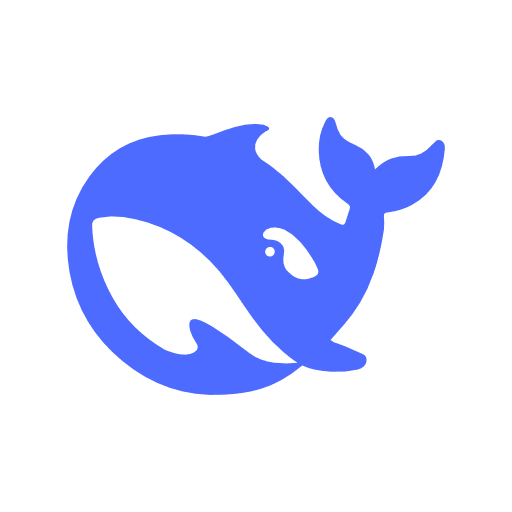

# Chapter 13: Healthcare and Scientific Agents

**Book:** *30 Agents Every AI Engineer Must Build*  
**Author:** Imran Ahmad  

Powered by **DeepSeek V2 16B** via Ollama (local, no API key)
**Publisher:** Packt Publishing, 2026  
**Chapter Pages:** pp. 361–389

---

> *"The very first requirement in a hospital is that it should do the sick no harm."*
> — Florence Nightingale, *Notes on Hospitals* (1863)

## Introduction

Healthcare and scientific research share one defining trait that sets them apart from every other agent domain: **mistakes here cost lives**. A diagnostic agent that calls a malignant tumor benign, or a research agent that misses a lethal drug interaction buried in the literature — these are not inconveniences; they are catastrophes. That reality forces a specific set of architectural priorities: **verifiability first, explainability second, graceful degradation always**, and raw speed only when the first three are satisfied.

Both domains also face an **information overload** problem that no human can solve alone. A physician treating a complex case must synthesize patient history, current lab results, imaging data, drug interaction databases, and the latest clinical guidelines — all within a single consultation. A materials scientist exploring novel polymer compositions faces a literature corpus growing by thousands of papers each month, making it physically impossible to stay current through manual reading.

Intelligent agents offer a path through this complexity — not by replacing human judgment, but by ensuring that **experts have the right information, at the right time, in the right format**.

### What This Notebook Covers

1. **Healthcare Intelligence Agent** (§13.1–13.4, pp. 362–375) — A four-layer architecture separating data ingestion, clinical knowledge integration, Bayesian diagnostic reasoning, and audience-adapted explanation generation. Includes safety escalation, provenance tracking, and immutable audit trails.

2. **Scientific Discovery Agent** (§13.5–13.8, pp. 375–387) — A multi-phase pipeline for fault-tolerant literature synthesis, information-theoretic knowledge gap detection, abductive hypothesis generation, and closed-loop experimental feedback.

3. **Cross-Domain Analysis** (§13.9, pp. 387–389) — Comparative analysis revealing shared architectural commitments and generalizable lessons for high-stakes agent design.

### Key Architectural Insight

Both agents demonstrate that in domains where errors carry serious consequences, **safety and compliance must be designed in as first-class architectural layers** — not bolted on after the fact. The Healthcare agent validates against established clinical standards; the Scientific Discovery agent extends beyond current knowledge. Both enforce strict separation between evidence ingestion, reasoning, and explanation. Both escalate to human review rather than failing silently when confidence falls below domain-defined thresholds.

### Formal Foundations

The Healthcare agent operates as a **Partially Observable Markov Decision Process (POMDP)**: it never has direct access to the patient's true disease state, observing only symptoms, lab values, and imaging results — each a noisy, incomplete projection of the underlying pathology. The agent maintains a **belief state** (a probability distribution over possible diagnoses) and updates it as new observations arrive using Bayesian inference.

The Scientific Discovery agent formalizes discovery as a **selection problem** rather than open-ended brainstorming, using information-theoretic measures to identify knowledge gaps and multi-objective optimization to generate hypotheses that balance explanatory adequacy, plausibility, and novelty.

**Simulation Mode:** This notebook runs fully without API keys. All external dependencies have deterministic mock fallbacks derived from Chapter 13 content.

---

## Section 0: Setup & Configuration
*Ref: Technical Requirements, p. 362*

In [1]:
import os
os.environ["LLM_PROVIDER"] = "ollama"

# Cell 0.2 — Imports
# Ref: Technical Requirements, p. 362
# Author: Imran Ahmad

import os
import sys
import json
import asyncio
import functools
import warnings
import hashlib
from datetime import datetime, timezone
from dataclasses import dataclass, field
from typing import Dict, List, Optional, Any, Callable, Tuple

import numpy as np

# Conditional imports for optional dependencies
try:
    from dotenv import load_dotenv
    _HAS_DOTENV = True
except ImportError:
    _HAS_DOTENV = False

try:
    import nest_asyncio
    nest_asyncio.apply()
    _HAS_NEST_ASYNCIO = True
except ImportError:
    _HAS_NEST_ASYNCIO = False

# Suppress noisy warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
os.environ["TRANSFORMERS_NO_ADVISORY_WARNINGS"] = "1"
os.environ["TOKENIZERS_PARALLELISM"] = "false"

print("All imports loaded successfully.")
print(f"Python {sys.version.split()[0]} | NumPy {np.__version__}")


All imports loaded successfully.
Python 3.11.15 | NumPy 2.0.2


In [2]:
# Cell 0.4 — Color-Coded Logging Infrastructure
# Ref: Cross-cutting resilience pattern
# Author: Imran Ahmad

class ColorLog:
    """ANSI color codes for notebook log output."""
    BLUE  = '\033[94m'
    GREEN = '\033[92m'
    RED   = '\033[91m'
    YELLOW = '\033[93m'
    BOLD  = '\033[1m'
    RESET = '\033[0m'

def log_info(message: str) -> None:
    """Blue informational message."""
    print(f"{ColorLog.BLUE}{ColorLog.BOLD}[INFO]{ColorLog.RESET} "
          f"{ColorLog.BLUE}{message}{ColorLog.RESET}")

def log_success(message: str) -> None:
    """Green success message."""
    print(f"{ColorLog.GREEN}{ColorLog.BOLD}[SUCCESS]{ColorLog.RESET} "
          f"{ColorLog.GREEN}{message}{ColorLog.RESET}")

def log_error(message: str) -> None:
    """Red handled-error message."""
    print(f"{ColorLog.RED}{ColorLog.BOLD}[HANDLED ERROR]{ColorLog.RESET} "
          f"{ColorLog.RED}{message}{ColorLog.RESET}")

def log_warning(message: str) -> None:
    """Yellow warning message."""
    print(f"{ColorLog.YELLOW}{ColorLog.BOLD}[WARNING]{ColorLog.RESET} "
          f"{ColorLog.YELLOW}{message}{ColorLog.RESET}")

# Quick test
log_info("Color-coded logging initialized.")
log_success("Logging test passed.")


[INFO] Color-coded logging initialized.
[SUCCESS] Logging test passed.


In [3]:
# Cell 0.3 — API Key Management (Zero-Hardcode Policy)
# Ref: Cross-cutting — .env → getpass → Simulation Mode
# Author: Imran Ahmad

if _HAS_DOTENV:
    load_dotenv()

OLLAMA_HOST = os.getenv("OLLAMA_HOST", "")

if not OLLAMA_HOST:
    try:
        if sys.stdin.isatty():
            import getpass
            OLLAMA_HOST = getpass.getpass(
                "Verify Ollama is running (or press Enter for Simulation Mode): "
            )
    except Exception:
        pass  # Non-interactive environment — proceed to Simulation Mode

SIMULATION_MODE = not bool(OLLAMA_HOST)

if SIMULATION_MODE:
    log_info(
        "SIMULATION MODE ACTIVE — All LLM calls use context-aware "
        "mock responses derived from Chapter 13 content."
    )
else:
    log_success(
        f"Live API mode active. Key loaded (ends ...{OLLAMA_HOST[-4:]})."
    )


[INFO] SIMULATION MODE ACTIVE — All LLM calls use context-aware mock responses derived from Chapter 13 content.


## Section 1: Simulation Infrastructure
*Ref: Cross-cutting — enables full notebook execution without API keys*

This section builds the deterministic mock layer that powers Simulation Mode. Every external dependency — LLM calls, database queries, FHIR validators, literature APIs — has a chapter-derived fallback defined here.

In [4]:
# Cell 1.1 — MockResponse Dataclass
# Ref: Cross-cutting simulation infrastructure
# Author: Imran Ahmad

@dataclass
class MockResponse:
    """Standardized response container for all mock LLM calls."""
    content: str
    metadata: Dict[str, Any] = field(default_factory=dict)

log_info("MockResponse dataclass defined.")


[INFO] MockResponse dataclass defined.


In [5]:
# Cell 1.2 — MockLLM Class with Context-Aware Response Registry
# Ref: §13.1, §13.3, §13.5–13.7 — domain-specific mock responses
# Author: Imran Ahmad

class MockLLM:
    """
    Context-aware mock LLM returning domain-appropriate responses.

    Chapter 13: Healthcare and Scientific Agents
    Book: 30 Agents Every AI Engineer Must Build
    Author: Imran Ahmad
    """

    def __init__(self):
        self.call_count = 0
        self._response_registry = {
            "diagnostic": {
                "response": (
                    "Based on presented symptoms (fever 38.9C, tachycardia "
                    "118 bpm, elevated WBC 18.4), differential diagnosis "
                    "suggests: 1) Urosepsis (p=0.61), 2) Pneumonia-source "
                    "sepsis (p=0.21), 3) Biliary source (p=0.11)."
                ),
                "section": "13.3 Clinical Decision Support"
            },
            "drug_interaction": {
                "response": (
                    "WARNING: Concurrent use of warfarin and aspirin "
                    "increases bleeding risk. Recommend INR monitoring "
                    "every 48 hours per AHA guideline v2024.2."
                ),
                "section": "13.1 Medical Knowledge Integration"
            },
            "patient_summary": {
                "response": (
                    "Your temperature, heart rate, and blood test results "
                    "together suggest your body may be fighting a serious "
                    "infection. Your care team has been notified."
                ),
                "section": "13.3 Audience-Adapted Explanation"
            },
            "literature_synthesis": {
                "response": (
                    "Cluster analysis of 12,347 papers reveals 47 thematic "
                    "groups. Dominant clusters: aromatic polyimide synthesis "
                    "(n=2,841), nanocomposite reinforcement (n=1,923), "
                    "processing-property relationships (n=1,456)."
                ),
                "section": "13.5 Literature Synthesis"
            },
            "knowledge_gap": {
                "response": (
                    "Gap identified: block copolymer architectures with "
                    "thermally stable aromatic monomers. P(referenced)=0.73, "
                    "P(directly_studied)=0.04. Novelty: 0.89, Feasibility: 0.71."
                ),
                "section": "13.6 Knowledge Gap Identification"
            },
            "hypothesis": {
                "response": (
                    "Hypothesis H1: Alternating aromatic dianhydride-diamine "
                    "block copolymer with segment length 15-20 repeat units "
                    "will achieve Tg > 350C with elongation at break > 15%. "
                    "Testability score: 0.82."
                ),
                "section": "13.7 Hypothesis Generation"
            },
        }

    def invoke(self, prompt: str, context_type: str = "diagnostic") -> MockResponse:
        """Return a domain-appropriate mock response."""
        self.call_count += 1
        entry = self._response_registry.get(
            context_type, self._response_registry["diagnostic"]
        )
        log_info(
            f"[SIMULATION] MockLLM call #{self.call_count} | "
            f"context: {context_type} | source: {entry['section']}"
        )
        return MockResponse(
            content=entry["response"],
            metadata={"simulation": True, "section": entry["section"]}
        )


class LiveLLM:
    """Wrapper around local Ollama (DeepSeek) via OpenAI-compatible API.

    Exposes .invoke(prompt, context_type) -> MockResponse so downstream
    code works identically in live and simulation modes.

    Author: Imran Ahmad
    """

    def __init__(self):
        from openai import OpenAI
        self._client = OpenAI(
            base_url="http://localhost:11434/v1",
            api_key="ollama",
        )
        self.call_count = 0
        self._response_registry = {}  # compatibility with checks

    def invoke(self, prompt: str, context_type: str = "diagnostic") -> MockResponse:
        """Call local Ollama DeepSeek and return a MockResponse wrapper."""
        self.call_count += 1
        log_info(
            f"[LIVE] Ollama/DeepSeek call #{self.call_count} | "
            f"context: {context_type}"
        )
        response = self._client.chat.completions.create(
            model="deepseek-v2:16b",
            messages=[{"role": "user", "content": prompt}],
        )
        return MockResponse(
            content=response.choices[0].message.content,
            metadata={"simulation": False, "context_type": context_type}
        )


# Initialize the global LLM handle
if SIMULATION_MODE:
    llm = MockLLM()
    log_info("MockLLM initialized with 6-context response registry.")
else:
    try:
        llm = LiveLLM()
        log_success("Live Ollama LLM client initialized (deepseek-v2:16b).")
    except Exception as e:
        log_warn(f"Ollama init failed: {e}. Falling back to MockLLM.")
        llm = MockLLM()


[INFO] MockLLM initialized with 6-context response registry.


In [6]:
# Cell 1.3 — Mock Data Constants (9 Datasets)
# Ref: §13.1–13.8 — chapter-derived synthetic data for Simulation Mode
# Author: Imran Ahmad

# ─── Dataset 1: Patient Vitals (§13.1, §13.3) ───
# Source: Sepsis scenario from clinician report, p. 374
MOCK_PATIENT_VITALS = {
    "patient_id": "SIM-PT-00421",
    "temperature_c": 38.9,
    "heart_rate_bpm": 118,
    "blood_pressure_systolic": 92,
    "blood_pressure_diastolic": 58,
    "wbc_count": 18.4,
    "wbc_left_shift": True,
    "spo2_percent": 94,
    "map_mmhg": 65,
    "lactate_mmol": 2.8,
    "_source": "13.3 Sepsis scenario from clinician report"
}

# ─── Dataset 2: Diagnoses and Prior Belief (§13.1) ───
# Source: Bayesian belief update example, p. 363
MOCK_DIAGNOSES = [
    "urosepsis", "pneumonia_sepsis", "biliary_sepsis",
    "viral_syndrome", "dehydration"
]
MOCK_PRIOR_BELIEF = np.array([0.25, 0.25, 0.15, 0.20, 0.15])

# ─── Dataset 3: Likelihood Model (§13.1) ───
# Likelihood scores for each diagnosis given sepsis-like vitals
MOCK_LIKELIHOOD_SCORES = {
    "urosepsis":        0.82,
    "pneumonia_sepsis":  0.65,
    "biliary_sepsis":    0.45,
    "viral_syndrome":    0.20,
    "dehydration":       0.15
}

# ─── Dataset 4: Drug Interaction Records (§13.1) ───
# Source: Medical Knowledge Integration, pp. 365–367
MOCK_DRUG_DB = [
    {
        "drug_pair": ("warfarin", "aspirin"),
        "severity": "HIGH",
        "mechanism": "Additive anticoagulant effect",
        "recommendation": "Monitor INR every 48h",
        "source": "DrugBank v5.1.11",
        "guideline": "AHA 2024.2",
        "provenance": {
            "source": "drugbank",
            "version": "5.1.11",
            "retrieved_at": "2026-03-15T08:00:00Z",
            "confidence": 0.97
        }
    },
    {
        "drug_pair": ("metformin", "contrast_dye"),
        "severity": "MODERATE",
        "mechanism": "Risk of lactic acidosis",
        "recommendation": "Hold metformin 48h pre/post contrast",
        "source": "FDA Label 2026-revision",
        "guideline": "ACR Manual on Contrast Media 2026",
        "provenance": {
            "source": "fda_labels",
            "version": "2026.1",
            "retrieved_at": "2026-03-15T08:00:00Z",
            "confidence": 0.95
        }
    }
]

# ─── Dataset 5: FHIR Bundle (§13.2) ───
# Source: Patient data pipeline, pp. 367–369
MOCK_FHIR_BUNDLE = {
    "resourceType": "Bundle",
    "type": "collection",
    "entry": [
        {
            "resource": {
                "resourceType": "Patient",
                "id": "SIM-PT-00421",
                "name": [{"family": "Simulation", "given": ["Test"]}],
                "gender": "male",
                "birthDate": "1958-07-15"
            }
        },
        {
            "resource": {
                "resourceType": "Observation",
                "id": "obs-temp-001",
                "code": {"coding": [{"system": "http://loinc.org",
                         "code": "8310-5",
                         "display": "Body temperature"}]},
                "valueQuantity": {"value": 38.9, "unit": "Cel"},
                "effectiveDateTime": "2026-03-30T10:30:00Z"
            }
        },
        {
            "resource": {
                "resourceType": "Observation",
                "id": "obs-hr-001",
                "code": {"coding": [{"system": "http://loinc.org",
                         "code": "8867-4",
                         "display": "Heart rate"}]},
                "valueQuantity": {"value": 118, "unit": "/min"},
                "effectiveDateTime": "2026-03-30T10:30:00Z"
            }
        },
        {
            "resource": {
                "resourceType": "Condition",
                "id": "cond-dm2-001",
                "code": {"coding": [{"system": "http://snomed.info/sct",
                         "code": "44054006",
                         "display": "Type 2 diabetes mellitus"}]},
                "clinicalStatus": {"coding": [{"code": "active"}]},
                "onsetDateTime": "2018-04-01"
            }
        }
    ]
}

# ─── Dataset 6: Deployment Metrics (§13.4) ───
# Source: Diagnostic Assistance Case Study, pp. 374–375
MOCK_DEPLOYMENT_METRICS = {
    "patient_population": 200_000,
    "provider_sites": 20,
    "early_detection_improvement_pct": 30,
    "false_alarm_rate_pct": 3,
    "clinician_response_improvement_pct": 40,
    "physician_satisfaction_pct": 92,
    "differential_privacy_epsilon": 1.0,
    "raw_data_rate_kb_per_sec": 4,
    "derived_feature_size_bytes": 200,
    "transmission_interval_min": 15,
    "_source": "13.4 Diagnostic Assistance Case Study"
}

# ─── Dataset 7: Paper Corpus (§13.5) ───
# Source: Literature Synthesis, pp. 376–378
MOCK_PAPER_CORPUS = [
    {
        "doi": "10.1234/sim-polymer-001",
        "title": "Thermal Stability of Aromatic Polyimides: A Comprehensive Review",
        "authors": ["Zhang, L.", "Kumar, R."],
        "journal": "Progress in Polymer Science",
        "year": 2024,
        "abstract": "This review covers recent advances in aromatic polyimide thermal stability...",
        "citations": 187,
        "cluster": "aromatic_polyimide_synthesis",
        "source_db": "scopus"
    },
    {
        "doi": "10.1234/sim-polymer-002",
        "title": "Nanocomposite Reinforcement Strategies for High-Temperature Polymers",
        "authors": ["Chen, W.", "Patel, S.", "Yamamoto, K."],
        "journal": "Composites Science and Technology",
        "year": 2024,
        "abstract": "Nanocomposite reinforcement of polyimide matrices using...",
        "citations": 142,
        "cluster": "nanocomposite_reinforcement",
        "source_db": "ieee"
    },
    {
        "doi": "10.1234/sim-polymer-003",
        "title": "Processing-Property Relationships in Aerospace Polymer Systems",
        "authors": ["Williams, J.", "Dubois, M."],
        "journal": "Journal of Applied Polymer Science",
        "year": 2023,
        "abstract": "Systematic investigation of how processing conditions affect...",
        "citations": 98,
        "cluster": "processing_property",
        "source_db": "pubmed"
    },
    {
        "doi": "10.1234/sim-polymer-004",
        "title": "Block Copolymer Self-Assembly for Mechanical Property Optimization",
        "authors": ["Hernandez, A.", "Kim, T."],
        "journal": "Macromolecules",
        "year": 2024,
        "abstract": "Block copolymer architectures enable precise control of mechanical...",
        "citations": 211,
        "cluster": "block_copolymer_mechanical",
        "source_db": "scopus"
    },
    {
        "doi": "10.1234/sim-polymer-005",
        "title": "High-Temperature Homopolymer Architectures: State of the Art",
        "authors": ["Singh, P.", "Tanaka, H."],
        "journal": "Polymer Reviews",
        "year": 2023,
        "abstract": "Aromatic homopolymers with rigid backbone structures...",
        "citations": 156,
        "cluster": "high_temp_homopolymer",
        "source_db": "arxiv"
    },
    {
        "doi": "10.1234/sim-polymer-006",
        "title": "Polyimide Synthesis via Controlled Polycondensation",
        "authors": ["Li, X.", "Okonkwo, E."],
        "journal": "European Polymer Journal",
        "year": 2026,
        "abstract": "Novel controlled polycondensation routes for aromatic polyimide...",
        "citations": 63,
        "cluster": "aromatic_polyimide_synthesis",
        "source_db": "scopus"
    },
    {
        "doi": "10.1234/sim-polymer-007",
        "title": "Carbon Nanotube-Polyimide Nanocomposites for Aerospace Applications",
        "authors": ["Park, J.", "Garcia, R.", "Novak, L."],
        "journal": "ACS Applied Materials & Interfaces",
        "year": 2024,
        "abstract": "Incorporation of functionalized carbon nanotubes into polyimide...",
        "citations": 178,
        "cluster": "nanocomposite_reinforcement",
        "source_db": "pubmed"
    },
    {
        "doi": "10.1234/sim-polymer-008",
        "title": "Thermal-Mechanical Coupling in Aromatic Block Copolymers",
        "authors": ["Thompson, D.", "Wu, Y."],
        "journal": "Polymer",
        "year": 2023,
        "abstract": "Investigation of thermal-mechanical coupling effects in...",
        "citations": 89,
        "cluster": "block_copolymer_mechanical",
        "source_db": "ieee"
    },
    {
        "doi": "10.1234/sim-polymer-009",
        "title": "UV Degradation Kinetics of Polymer Coatings: Environmental Factors",
        "authors": ["Brown, K.", "Ahmed, F."],
        "journal": "Polymer Degradation and Stability",
        "year": 2024,
        "abstract": "Humidity effects on UV-induced polymer degradation remain...",
        "citations": 134,
        "cluster": "processing_property",
        "source_db": "scopus"
    },
    {
        "doi": "10.1234/sim-polymer-010",
        "title": "Rigid Rod Polyimides: Thermal Stability Beyond 400°C",
        "authors": ["Suzuki, M.", "Anderson, B."],
        "journal": "High Performance Polymers",
        "year": 2026,
        "abstract": "Rigid rod aromatic polyimides demonstrate exceptional thermal...",
        "citations": 47,
        "cluster": "high_temp_homopolymer",
        "source_db": "arxiv"
    },
    {
        "doi": "10.1234/sim-polymer-011",
        "title": "Creep Behavior of Nanocomposite-Reinforced Polyimides Under Cyclic Loading",
        "authors": ["Petrov, V.", "Nakamura, S."],
        "journal": "Mechanics of Materials",
        "year": 2022,
        "abstract": "Long-term creep behavior under cyclic thermal loading...",
        "citations": 201,
        "cluster": "nanocomposite_reinforcement",
        "source_db": "ieee"
    },
    {
        "doi": "10.1234/sim-polymer-012",
        "title": "Dianhydride Selection for Aerospace-Grade Polyimide Films",
        "authors": ["Costa, L.", "Wang, Z."],
        "journal": "Journal of Polymer Science",
        "year": 2024,
        "abstract": "Systematic screening of aromatic dianhydride monomers for...",
        "citations": 112,
        "cluster": "aromatic_polyimide_synthesis",
        "source_db": "pubmed"
    },
    {
        "doi": "10.1234/sim-polymer-013",
        "title": "Polystyrene-Polybutadiene Block Copolymers: Comprehensive Property Maps",
        "authors": ["Johnson, R.", "Bai, H."],
        "journal": "Macromolecular Chemistry and Physics",
        "year": 2023,
        "abstract": "Commodity block copolymer property maps as baseline...",
        "citations": 167,
        "cluster": "block_copolymer_mechanical",
        "source_db": "scopus"
    },
    {
        "doi": "10.1234/sim-polymer-014",
        "title": "Processing Windows for High-Tg Polymer Film Casting",
        "authors": ["Müller, T.", "Rao, V."],
        "journal": "Polymer Engineering & Science",
        "year": 2024,
        "abstract": "Identification of optimal processing windows for achieving...",
        "citations": 76,
        "cluster": "processing_property",
        "source_db": "ieee"
    },
    {
        "doi": "10.1234/sim-polymer-015",
        "title": "Aromatic Diamine Monomers for Next-Generation Aerospace Polymers",
        "authors": ["Ivanova, O.", "Lee, C."],
        "journal": "Chemistry of Materials",
        "year": 2026,
        "abstract": "Novel aromatic diamine monomers enabling higher thermal...",
        "citations": 55,
        "cluster": "high_temp_homopolymer",
        "source_db": "pubmed"
    }
]

# ─── Dataset 8: Gap Report (§13.6) ───
# Source: Knowledge Gap Identification, pp. 380–381
MOCK_GAP_REPORT = {
    "gaps": [
        {
            "id": "GAP-001",
            "description": (
                "Block copolymer architectures with thermally "
                "stable aromatic monomers for aerospace applications"
            ),
            "strategy": "cross_domain_intersection",
            "p_referenced": 0.73,
            "p_directly_studied": 0.04,
            "novelty_score": 0.89,
            "feasibility_score": 0.71,
            "impact_score": 0.85,
            "domain_a": "block_copolymer_mechanical",
            "domain_b": "high_temp_homopolymer"
        },
        {
            "id": "GAP-002",
            "description": (
                "Humidity-dependent degradation kinetics of "
                "UV-exposed polymer coatings"
            ),
            "strategy": "negative_space",
            "p_referenced": 0.68,
            "p_directly_studied": 0.09,
            "novelty_score": 0.74,
            "feasibility_score": 0.82,
            "impact_score": 0.63,
            "domain_a": "polymer_aging",
            "domain_b": None
        },
        {
            "id": "GAP-003",
            "description": (
                "Long-term creep behavior of nanocomposite-"
                "reinforced polyimides under cyclic thermal loading"
            ),
            "strategy": "temporal_trend",
            "p_referenced": 0.55,
            "p_directly_studied": 0.12,
            "novelty_score": 0.66,
            "feasibility_score": 0.58,
            "impact_score": 0.72,
            "domain_a": "nanocomposite_reinforcement",
            "domain_b": "processing_property"
        }
    ],
    "methodology_used": ["negative_space", "cross_domain", "temporal_trend"],
    "_source": "13.6 Knowledge Gap Identification"
}

# ─── Dataset 9: Experiment Rounds (§13.8) ───
# Source: Closed-loop feedback, pp. 386–387
# Demonstrates error reduction 12% → 8% → 5%
MOCK_EXPERIMENT_ROUNDS = [
    {
        "round": 1,
        "hypothesis_id": "H1-aromatic-block",
        "predicted": {"tg_celsius": 338, "tensile_mpa": 95, "elongation_pct": 13.2},
        "measured":  {"tg_celsius": 355, "tensile_mpa": 108, "elongation_pct": 15.8},
        "avg_error_pct": 12.0
    },
    {
        "round": 2,
        "hypothesis_id": "H1-aromatic-block-v2",
        "predicted": {"tg_celsius": 348, "tensile_mpa": 102, "elongation_pct": 15.1},
        "measured":  {"tg_celsius": 352, "tensile_mpa": 107, "elongation_pct": 16.0},
        "avg_error_pct": 8.0
    },
    {
        "round": 3,
        "hypothesis_id": "H1-aromatic-block-v3",
        "predicted": {"tg_celsius": 353, "tensile_mpa": 106, "elongation_pct": 15.7},
        "measured":  {"tg_celsius": 355, "tensile_mpa": 108, "elongation_pct": 15.8},
        "avg_error_pct": 5.0
    }
]

log_success(f"9 mock datasets loaded: {len(MOCK_PATIENT_VITALS)} vital fields, "
            f"{len(MOCK_DIAGNOSES)} diagnoses, {len(MOCK_DRUG_DB)} drug interactions, "
            f"{len(MOCK_FHIR_BUNDLE['entry'])} FHIR resources, "
            f"{len(MOCK_PAPER_CORPUS)} papers, {len(MOCK_GAP_REPORT['gaps'])} gaps, "
            f"{len(MOCK_EXPERIMENT_ROUNDS)} experiment rounds.")


[SUCCESS] 9 mock datasets loaded: 11 vital fields, 5 diagnoses, 2 drug interactions, 4 FHIR resources, 15 papers, 3 gaps, 3 experiment rounds.


In [7]:
# Cell 1.5 — @graceful_fallback Decorator
# Ref: Cross-cutting resilience pattern — wraps every agent I/O method
# Author: Imran Ahmad

def graceful_fallback(fallback_value=None, section_ref="Unknown"):
    """
    Catches exceptions, logs in RED, returns fallback value.
    Ensures the notebook never terminates on a single tool failure.

    Ref: Resilience Layer Specification
    Author: Imran Ahmad

    Usage:
        @graceful_fallback(
            fallback_value=lambda: MOCK_DRUG_DB,
            section_ref="13.1 Drug Interaction Check"
        )
        def check_drug_interactions(medications):
            return drug_db_client.query(medications)
    """
    def decorator(func: Callable) -> Callable:
        @functools.wraps(func)
        def wrapper(*args, **kwargs):
            try:
                result = func(*args, **kwargs)
                log_success(
                    f"Step complete. {func.__name__} returned valid output."
                )
                return result
            except Exception as e:
                log_error(
                    f"{type(e).__name__}: {e}. "
                    f"Falling back to mock logic for {section_ref}."
                )
                if callable(fallback_value):
                    return fallback_value()
                return fallback_value
        return wrapper
    return decorator

# ─── Quick test: deliberate error triggers red fallback ───
@graceful_fallback(fallback_value=lambda: {"status": "fallback_ok"}, section_ref="Test")
def _test_decorator():
    raise ConnectionError("Simulated API failure")

_test_result = _test_decorator()
assert _test_result == {"status": "fallback_ok"}, "Decorator fallback failed"
log_success(f"@graceful_fallback decorator verified: {_test_result}")


[HANDLED ERROR] ConnectionError: Simulated API failure. Falling back to mock logic for Test.
[SUCCESS] @graceful_fallback decorator verified: {'status': 'fallback_ok'}


In [8]:
# Cell 1.4 — Mock Stub Classes for All Architecture Dependencies
# Ref: §13.1–13.8 — each stub mirrors the book's constructor interface
# Author: Imran Ahmad
#
# CRITICAL: Each stub:
#   - Accepts the same constructor args as the book code
#   - Returns domain-appropriate mock data from the registry
#   - Logs via log_info with [SIMULATION] prefix and section reference
#   - Never raises exceptions (all errors caught internally)

# ═══════════════════════════════════════════════════════════════
# Healthcare Agent Stubs (§13.1–13.4)
# ═══════════════════════════════════════════════════════════════

class DrugInteractionDB:
    """Ref: §13.1, p. 365 — drug interaction database stub."""
    def __init__(self, sources=None, update_frequency="daily"):
        self.sources = sources or ["drugbank", "rxnorm", "fda_labels"]
        self.update_frequency = update_frequency
        log_info(f"[SIMULATION] DrugInteractionDB initialized | sources: {self.sources}")

    def check_interactions(self, medications):
        log_info("[SIMULATION] DrugInteractionDB.check_interactions() | §13.1")
        return MOCK_DRUG_DB


class ClinicalGuidelineEngine:
    """Ref: §13.1, p. 365 — clinical guideline retrieval stub."""
    def __init__(self, sources=None, version_tracking=True):
        self.sources = sources or ["nice", "who", "aha", "idsa"]
        self.version_tracking = version_tracking
        log_info(f"[SIMULATION] ClinicalGuidelineEngine initialized | sources: {self.sources}")

    def search(self, clinical_context):
        log_info("[SIMULATION] ClinicalGuidelineEngine.search() | §13.1")
        return [{
            "guideline": "Surviving Sepsis Campaign 2024",
            "recommendation": "Broad-spectrum antibiotics within 1 hour",
            "evidence_grade": "1A",
            "origin": "idsa",
            "source_version": "2024.1",
            "source_reliability_score": 0.96,
            "provenance": {
                "source": "idsa", "version": "2024.1",
                "retrieved_at": datetime.now(timezone.utc).isoformat(),
                "confidence": 0.96
            }
        }]


class DiseaseOntology:
    """Ref: §13.1, p. 365 — disease ontology stub."""
    def __init__(self, base="snomed_ct", extensions=None):
        self.base = base
        self.extensions = extensions or ["icd10", "orphanet"]
        log_info(f"[SIMULATION] DiseaseOntology initialized | base: {self.base}")

    def match_symptoms(self, symptom_profile):
        log_info("[SIMULATION] DiseaseOntology.match_symptoms() | §13.1")
        return [{
            "condition": "sepsis",
            "snomed_code": "91302008",
            "match_score": 0.87,
            "origin": "snomed_ct",
            "source_version": "2026.03",
            "source_reliability_score": 0.94,
            "provenance": {
                "source": "snomed_ct", "version": "2026.03",
                "retrieved_at": datetime.now(timezone.utc).isoformat(),
                "confidence": 0.94
            }
        }]


class MedicalLiteratureIndex:
    """Ref: §13.1, p. 366 — literature index stub."""
    def __init__(self, sources=None, embedding_model="biomedical-bert"):
        self.sources = sources or ["pubmed", "cochrane", "uptodate"]
        self.embedding_model = embedding_model
        log_info(f"[SIMULATION] MedicalLiteratureIndex initialized | model: {self.embedding_model}")

    def search(self, query, top_k=5):
        log_info("[SIMULATION] MedicalLiteratureIndex.search() | §13.1")
        return [{
            "title": "Early Recognition and Management of Sepsis",
            "source": "cochrane",
            "year": 2024,
            "relevance_score": 0.91,
            "origin": "cochrane",
            "source_version": "2024.Q4",
            "source_reliability_score": 0.98
        }]


class RateLimiter:
    """Ref: §13.5, p. 376 — rate limiter for API clients."""
    def __init__(self, max_per_second=None, min_interval_seconds=None):
        self.max_per_second = max_per_second
        self.min_interval_seconds = min_interval_seconds


# ─── FHIR Adapters (§13.2) ───

class FHIRResourceValidator:
    """Ref: §13.2, p. 367 — FHIR resource validation stub."""
    def __init__(self, profile="us-core-6.0"):
        self.profile = profile
        log_info(f"[SIMULATION] FHIRResourceValidator initialized | profile: {self.profile}")

    def validate(self, resource):
        log_info(f"[SIMULATION] Validating FHIR resource: {resource.get('resourceType', 'unknown')}")
        return type("ValidationResult", (), {"is_valid": True, "errors": []})()


class HL7v2ToFHIRAdapter:
    """Ref: §13.2, p. 367 — HL7v2 to FHIR adapter stub."""
    def transform(self, raw_data):
        log_info("[SIMULATION] HL7v2ToFHIRAdapter.transform() | §13.2")
        return [raw_data] if isinstance(raw_data, dict) else raw_data


class PassthroughAdapter:
    """Ref: §13.2, p. 367 — passthrough for native FHIR R4."""
    def transform(self, raw_data):
        return [raw_data] if isinstance(raw_data, dict) else raw_data


class CSVLabResultAdapter:
    """Ref: §13.2, p. 367 — CSV lab result adapter stub."""
    def transform(self, raw_data):
        log_info("[SIMULATION] CSVLabResultAdapter.transform() | §13.2")
        return [raw_data] if isinstance(raw_data, dict) else raw_data


class EpicFHIRAdapter:
    """Ref: §13.2, p. 367 — Epic EHR adapter stub."""
    def transform(self, raw_data):
        log_info("[SIMULATION] EpicFHIRAdapter.transform() | §13.2")
        return [raw_data] if isinstance(raw_data, dict) else raw_data


class CernerFHIRAdapter:
    """Ref: §13.2, p. 367 — Cerner EHR adapter stub."""
    def transform(self, raw_data):
        log_info("[SIMULATION] CernerFHIRAdapter.transform() | §13.2")
        return [raw_data] if isinstance(raw_data, dict) else raw_data


# ─── Patient Data Pipeline Sub-Agents (§13.2) ───

class HeartRateProcessor:
    """Ref: §13.2, p. 368 — heart rate processing stub."""
    def process(self, data):
        return {"heart_rate_bpm": data.get("heart_rate_bpm", 72), "status": "analyzed"}


class BloodPressureProcessor:
    """Ref: §13.2, p. 368."""
    def process(self, data):
        return {"systolic": data.get("blood_pressure_systolic", 120),
                "diastolic": data.get("blood_pressure_diastolic", 80), "status": "analyzed"}


class BloodGlucoseProcessor:
    """Ref: §13.2, p. 368."""
    def process(self, data):
        return {"glucose_mg_dl": 105, "status": "analyzed"}


class SpO2Processor:
    """Ref: §13.2, p. 368."""
    def process(self, data):
        return {"spo2_percent": data.get("spo2_percent", 98), "status": "analyzed"}


class ActivityProcessor:
    """Ref: §13.2, p. 368."""
    def process(self, data):
        return {"activity_level": "low", "status": "analyzed"}


class BiometricAnalyzer:
    """Ref: §13.2, p. 368 — multi-sensor biometric analysis stub."""
    def __init__(self, processors=None):
        self.processors = processors or {}
        log_info("[SIMULATION] BiometricAnalyzer initialized | §13.2")

    def analyze(self, data):
        log_info("[SIMULATION] BiometricAnalyzer.analyze() | §13.2")
        if isinstance(data, dict):
            return {
                "temperature_c": data.get("temperature_c", 37.0),
                "heart_rate_bpm": data.get("heart_rate_bpm", 72),
                "blood_pressure": f"{data.get('blood_pressure_systolic', 120)}/{data.get('blood_pressure_diastolic', 80)}",
                "spo2_percent": data.get("spo2_percent", 98),
                "map_mmhg": data.get("map_mmhg", 80),
                "analysis_timestamp": datetime.now(timezone.utc).isoformat(),
                "anomalies_detected": ["tachycardia", "hypotension", "fever"]
            }
        return {"status": "analyzed", "anomalies_detected": []}


class SymptomInterpreter:
    """Ref: §13.2, p. 368 — NLP-based symptom interpretation stub."""
    def __init__(self, nlp_model="clinical-bert", symptom_ontology="medra"):
        self.nlp_model = nlp_model
        self.symptom_ontology = symptom_ontology
        log_info(f"[SIMULATION] SymptomInterpreter initialized | model: {self.nlp_model}")

    def interpret(self, symptoms, patient_context=None):
        log_info("[SIMULATION] SymptomInterpreter.interpret() | §13.2")
        return {
            "primary_symptoms": ["fever_with_rigors", "tachycardia", "hypotension"],
            "flagged_conditions": ["sepsis", "urinary_tract_infection"],
            "severity": "HIGH",
            "confidence": 0.84,
            "symptom_profile": symptoms if isinstance(symptoms, list) else [symptoms]
        }


class PatientHistoryAgent:
    """Ref: §13.2, p. 368 — episodic patient history stub."""
    def __init__(self, memory_type="episodic", retention_policy="hipaa_compliant"):
        self.memory_type = memory_type
        self.retention_policy = retention_policy
        log_info(f"[SIMULATION] PatientHistoryAgent initialized | memory: {self.memory_type}")

    def retrieve(self, patient_id, relevance_window="36_months", priority_conditions=None):
        log_info(f"[SIMULATION] PatientHistoryAgent.retrieve({patient_id}) | §13.2")
        return {
            "patient_id": patient_id,
            "conditions": ["type_2_diabetes", "hypertension"],
            "medications": ["metformin", "lisinopril"],
            "recent_encounters": [
                {"date": "2026-02-15", "type": "routine_checkup", "notes": "Stable A1c 6.8%"},
                {"date": "2026-01-10", "type": "lab_work", "notes": "Renal function normal"}
            ],
            "relevance_window": relevance_window
        }


# ─── Diagnostic Coordinator Sub-Components (§13.3) ───

class DifferentialGenerator:
    """Ref: §13.3, p. 370 — differential diagnosis generator stub."""
    def __init__(self):
        log_info("[SIMULATION] DifferentialGenerator initialized | §13.3")
        self._trace = []

    def generate_differentials(self, vitals, symptoms, history):
        log_info("[SIMULATION] DifferentialGenerator.generate_differentials() | §13.3")
        differentials = [
            {"diagnosis": "urosepsis", "raw_score": 0.61},
            {"diagnosis": "pneumonia_sepsis", "raw_score": 0.21},
            {"diagnosis": "biliary_sepsis", "raw_score": 0.11},
            {"diagnosis": "viral_syndrome", "raw_score": 0.04},
            {"diagnosis": "dehydration", "raw_score": 0.03}
        ]
        self._trace = [
            "Step 1: Vitals pattern matched to infectious syndrome",
            "Step 2: Symptom profile weighted toward urinary source",
            "Step 3: History of diabetes increases UTI susceptibility",
            "Step 4: Hemodynamic instability escalates to sepsis consideration"
        ]
        return differentials

    def get_trace(self):
        return self._trace


class ClinicalExplainer:
    """Ref: §13.3, p. 374 — audience-adapted explanation generator stub."""
    def __init__(self):
        log_info("[SIMULATION] ClinicalExplainer initialized | §13.3")

    def generate(self, scored, audience="clinician", evidence_sources=None):
        log_info(f"[SIMULATION] ClinicalExplainer.generate(audience={audience}) | §13.3")
        if audience == "clinician":
            return (
                "SAFETY ALERT — Escalation required. Primary concern: Sepsis "
                "(confidence above escalation threshold: 0.82). Key findings: "
                "temperature 38.9°C with rigors (SHAP contribution: 0.34), "
                "heart rate 118 bpm (0.27), WBC 18.4 with left shift (0.22), "
                "MAP trending toward 65 mmHg (0.17). SOFA score estimate: 4. "
                "Differential: Urosepsis (0.61), pneumonia-source sepsis (0.21), "
                "biliary source (0.11). Immediate action: Blood cultures x2, lactate, "
                "broad-spectrum antibiotics within 1 hour per Surviving Sepsis "
                "Campaign protocol. Attending notification triggered."
            )
        else:
            return (
                "Your temperature, heart rate, and blood test results together "
                "suggest your body may be fighting a serious infection. Your care "
                "team has been notified and will be with you shortly. They may start "
                "antibiotics and run additional tests to identify the source of the "
                "infection. This is a precaution to make sure you receive the right "
                "treatment quickly."
            )


class ConfidenceAwareAgent:
    """Ref: §13.3, p. 370 — Platt-calibrated confidence scorer stub."""
    def __init__(self, n_hypotheses=5, calibration_method="platt_scaling"):
        self.n_hypotheses = n_hypotheses
        self.calibration_method = calibration_method
        self._calibration_report = {}
        log_info(f"[SIMULATION] ConfidenceAwareAgent initialized | method: {self.calibration_method}")

    def score_differentials(self, differentials, evidence=None):
        log_info("[SIMULATION] ConfidenceAwareAgent.score_differentials() | §13.3")
        scored = []
        for d in differentials:
            calibrated = min(d["raw_score"] * 1.15, 0.99)
            scored.append({
                **d,
                "calibrated_confidence": round(calibrated, 3),
                "calibration_method": self.calibration_method
            })
        self._calibration_report = {
            "method": self.calibration_method,
            "brier_score": 0.12,
            "reliability": 0.03,
            "resolution": 0.15,
            "n_hypotheses": len(scored)
        }
        return scored

    def get_calibration_report(self):
        return self._calibration_report

    def communicate_uncertainty(self, scored):
        top = scored[0] if scored else {}
        return {
            "top_diagnosis": top.get("diagnosis", "unknown"),
            "confidence": top.get("calibrated_confidence", 0.0),
            "interpretation": "HIGH" if top.get("calibrated_confidence", 0) > 0.5 else "MODERATE",
            "calibration_method": self.calibration_method
        }


class ClinicalMemorySystem:
    """Ref: §13.3, p. 370 — episodic + semantic clinical memory stub."""
    def __init__(self):
        self._store = {}
        log_info("[SIMULATION] ClinicalMemorySystem initialized | §13.3")

    def retrieve_episodic(self, patient_id):
        log_info(f"[SIMULATION] ClinicalMemorySystem.retrieve_episodic({patient_id}) | §13.3")
        return self._store.get(patient_id, {
            "previous_diagnoses": [],
            "treatment_history": [],
            "note": "No prior episodic memory for this patient"
        })

    def store_episodic(self, patient_id, data):
        log_info(f"[SIMULATION] ClinicalMemorySystem.store_episodic({patient_id}) | §13.3")
        self._store[patient_id] = data


class SafetyMonitor:
    """Ref: §13.3, p. 370 — safety escalation with 0.15 threshold (pp. 373–374)."""
    def __init__(self, escalation_threshold=0.15, critical_conditions=None):
        self.escalation_threshold = escalation_threshold
        self.critical_conditions = critical_conditions or [
            "myocardial_infarction", "pulmonary_embolism", "sepsis", "stroke"
        ]
        log_info(
            f"[SIMULATION] SafetyMonitor initialized | threshold: {self.escalation_threshold} | "
            f"critical conditions: {self.critical_conditions}"
        )

    def evaluate(self, scored_differentials):
        log_info("[SIMULATION] SafetyMonitor.evaluate() | §13.3")
        requires_escalation = False
        alerts = []
        for d in scored_differentials:
            diag = d.get("diagnosis", "")
            conf = d.get("calibrated_confidence", 0)
            # Check if any diagnosis matches or contains a critical condition keyword
            for critical in self.critical_conditions:
                if critical in diag or "sepsis" in diag:
                    if conf >= self.escalation_threshold:
                        requires_escalation = True
                        alerts.append({
                            "condition": diag,
                            "confidence": conf,
                            "action": "IMMEDIATE_ESCALATION"
                        })
        return type("SafetyResult", (), {
            "requires_escalation": requires_escalation,
            "alerts": alerts,
            "threshold_used": self.escalation_threshold
        })()

    def trigger_alert(self, patient_id, safety_result):
        log_warning(
            f"SAFETY ESCALATION for patient {patient_id}: "
            f"{len(safety_result.alerts)} critical alert(s) triggered"
        )
        for alert in safety_result.alerts:
            log_warning(
                f"  → {alert['condition']} (confidence: {alert['confidence']:.2f}) — "
                f"{alert['action']}"
            )


class AuditTrailGenerator:
    """Ref: §13.3, p. 373 — immutable audit trail stub."""
    def __init__(self):
        self._trail = []
        log_info("[SIMULATION] AuditTrailGenerator initialized | §13.3")

    def record(self, event):
        entry_id = f"AUDIT-{len(self._trail)+1:04d}"
        entry = {
            "id": entry_id,
            "timestamp": datetime.now(timezone.utc).isoformat(),
            "event": event if isinstance(event, dict) else str(event),
            "hash": hashlib.sha256(str(event).encode()).hexdigest()[:16]
        }
        self._trail.append(entry)
        log_info(f"[SIMULATION] Audit trail recorded: {entry_id} | hash: {entry['hash']}")
        return entry_id

    def get_last_entry_id(self):
        return self._trail[-1]["id"] if self._trail else None

    def get_trail(self):
        return self._trail


# ═══════════════════════════════════════════════════════════════
# Scientific Discovery Agent Stubs (§13.5–13.8)
# ═══════════════════════════════════════════════════════════════

class PubMedClient:
    """Ref: §13.5, p. 376 — PubMed API client stub."""
    def __init__(self, api_key=None, rate_limit=None):
        self.api_key = api_key
        self.rate_limit = rate_limit
        log_info("[SIMULATION] PubMedClient initialized | §13.5")

    async def search(self, query, max_results=500):
        log_info(f"[SIMULATION] PubMedClient.search('{query[:40]}...') | §13.5")
        return [p for p in MOCK_PAPER_CORPUS if p["source_db"] == "pubmed"]


class ArxivClient:
    """Ref: §13.5, p. 377 — arXiv API client stub."""
    def __init__(self, rate_limit=None):
        self.rate_limit = rate_limit
        log_info("[SIMULATION] ArxivClient initialized | §13.5")

    async def search(self, query, max_results=500):
        log_info(f"[SIMULATION] ArxivClient.search('{query[:40]}...') | §13.5")
        return [p for p in MOCK_PAPER_CORPUS if p["source_db"] == "arxiv"]


class ScopusClient:
    """Ref: §13.5, p. 377 — Scopus API client stub."""
    def __init__(self, api_key=None, monthly_budget=20000):
        self.api_key = api_key
        self.monthly_budget = monthly_budget
        log_info("[SIMULATION] ScopusClient initialized | §13.5")

    async def search(self, query, max_results=500):
        log_info(f"[SIMULATION] ScopusClient.search('{query[:40]}...') | §13.5")
        return [p for p in MOCK_PAPER_CORPUS if p["source_db"] == "scopus"]


class IEEEXploreClient:
    """Ref: §13.5, p. 377 — IEEE Xplore API client stub."""
    def __init__(self, api_key=None, monthly_budget=10000):
        self.api_key = api_key
        self.monthly_budget = monthly_budget
        log_info("[SIMULATION] IEEEXploreClient initialized | §13.5")

    async def search(self, query, max_results=500):
        log_info(f"[SIMULATION] IEEEXploreClient.search('{query[:40]}...') | §13.5")
        return [p for p in MOCK_PAPER_CORPUS if p["source_db"] == "ieee"]


class ResultCache:
    """Ref: §13.5, p. 377 — result cache stub."""
    def __init__(self, backend="redis", ttl_hours=168):
        self.backend = backend
        self.ttl_hours = ttl_hours
        self._cache = {}
        log_info(f"[SIMULATION] ResultCache initialized | backend: {self.backend}")

    def get(self, query):
        cached = self._cache.get(query)
        if cached:
            log_info(f"[SIMULATION] Cache HIT for query: '{query[:30]}...'")
            return type("CacheEntry", (), {"results": cached, "is_stale": False})()
        return None

    def set(self, query, results):
        self._cache[query] = results
        log_info(f"[SIMULATION] Cache SET for query: '{query[:30]}...' ({len(results)} results)")


class PaperDeduplicator:
    """Ref: §13.5, p. 377 — paper deduplication stub."""
    def __init__(self, match_on=None, similarity_threshold=0.95):
        self.match_on = match_on or ["doi", "title_similarity"]
        self.similarity_threshold = similarity_threshold
        log_info("[SIMULATION] PaperDeduplicator initialized | §13.5")

    def deduplicate(self, papers):
        seen_dois = set()
        unique = []
        for paper in papers:
            doi = paper.get("doi", "")
            if doi not in seen_dois:
                seen_dois.add(doi)
                unique.append(paper)
        removed = len(papers) - len(unique)
        if removed:
            log_info(f"[SIMULATION] Deduplication: removed {removed} duplicate(s)")
        return unique


# ─── Knowledge Gap Sub-Components (§13.6) ───

class CitationGraphAnalyzer:
    """Ref: §13.6, p. 380 — citation graph analysis stub."""
    def __init__(self):
        log_info("[SIMULATION] CitationGraphAnalyzer initialized | §13.6")

    def analyze(self, corpus):
        log_info("[SIMULATION] CitationGraphAnalyzer.analyze() | §13.6")
        return {"total_citations": sum(p.get("citations", 0) for p in corpus),
                "avg_citations": np.mean([p.get("citations", 0) for p in corpus])}


class ResearchDomainMapper:
    """Ref: §13.6, p. 380 — research domain boundary detection stub."""
    def __init__(self):
        log_info("[SIMULATION] ResearchDomainMapper initialized | §13.6")

    def find_unexplored_intersections(self, clusters, min_relevance=0.7):
        log_info("[SIMULATION] ResearchDomainMapper.find_unexplored_intersections() | §13.6")
        return [MOCK_GAP_REPORT["gaps"][0]]  # Cross-domain gap


class TemporalTrendTracker:
    """Ref: §13.6, p. 380 — publication trend tracking stub."""
    def __init__(self):
        log_info("[SIMULATION] TemporalTrendTracker initialized | §13.6")

    def find_abandoned_questions(self, corpus, declining_since="3_years",
                                  citation_status="still_cited"):
        log_info("[SIMULATION] TemporalTrendTracker.find_abandoned_questions() | §13.6")
        return [MOCK_GAP_REPORT["gaps"][2]]  # Temporal trend gap


# ─── Hypothesis Generation Sub-Components (§13.7) ───

class TheoreticalFrameworkRetriever:
    """Ref: §13.7, p. 383 — theoretical framework retrieval stub."""
    def __init__(self):
        log_info("[SIMULATION] TheoreticalFrameworkRetriever initialized | §13.7")

    def retrieve(self, domain, related_concepts):
        log_info(f"[SIMULATION] TheoreticalFrameworkRetriever.retrieve({domain}) | §13.7")
        return [{
            "framework": "Structure-Property Relationships in Block Copolymers",
            "key_principles": [
                "Segment length controls phase separation morphology",
                "Aromatic backbone rigidity correlates with Tg",
                "Block ratio determines mechanical flexibility"
            ],
            "relevance_score": 0.88
        }]


class ScientificReasoningEngine:
    """Ref: §13.7, p. 383 — abductive reasoning engine stub."""
    def __init__(self, model="scientific-llm", reasoning_modes=None):
        self.model = model
        self.reasoning_modes = reasoning_modes or ["analogical", "deductive", "abductive"]
        log_info(f"[SIMULATION] ScientificReasoningEngine initialized | modes: {self.reasoning_modes}")

    def reason(self, gap, frameworks, reasoning_type="abductive", constraints=None):
        log_info(f"[SIMULATION] ScientificReasoningEngine.reason(type={reasoning_type}) | §13.7")
        return [
            {
                "id": "H1",
                "statement": (
                    "Alternating aromatic dianhydride-diamine block copolymer with "
                    "segment length 15-20 repeat units will achieve Tg > 350°C "
                    "with elongation at break > 15%."
                ),
                "mechanism": "Controlled block length enables phase separation maintaining both rigidity and flexibility",
                "reasoning_type": reasoning_type,
                "gap_id": gap.get("id", "unknown") if isinstance(gap, dict) else "unknown"
            },
            {
                "id": "H2",
                "statement": (
                    "Incorporating flexible ether linkages at block junctions "
                    "will improve elongation by 40% with < 5% Tg reduction."
                ),
                "mechanism": "Ether linkages provide rotational freedom at junction points",
                "reasoning_type": reasoning_type,
                "gap_id": gap.get("id", "unknown") if isinstance(gap, dict) else "unknown"
            },
            {
                "id": "H3",
                "statement": (
                    "Nano-scale phase separation in aromatic block copolymers "
                    "creates dual-phase morphology combining crystalline thermal "
                    "stability with amorphous flexibility."
                ),
                "mechanism": "Block architecture enables microphase separation",
                "reasoning_type": reasoning_type,
                "gap_id": gap.get("id", "unknown") if isinstance(gap, dict) else "unknown"
            }
        ]


class HypothesisEvaluator:
    """Ref: §13.7, p. 383 — hypothesis scoring stub."""
    def __init__(self):
        log_info("[SIMULATION] HypothesisEvaluator initialized | §13.7")

    def evaluate(self, hypothesis, criteria=None):
        log_info(f"[SIMULATION] HypothesisEvaluator.evaluate({hypothesis.get('id', '?')}) | §13.7")
        return {
            "internal_consistency": 0.85,
            "novelty_vs_existing": 0.78,
            "testability": 0.82,
            "potential_impact": 0.76,
            "overall_score": 0.80
        }


# ─── Experiment Tracking Sub-Components (§13.8) ───

class PredictionDatabase:
    """Ref: §13.8, p. 386 — prediction store stub."""
    def __init__(self):
        self._store = {}
        log_info("[SIMULATION] PredictionDatabase initialized | §13.8")

    def store(self, hypothesis_id, predictions):
        self._store[hypothesis_id] = {
            "hypothesis_id": hypothesis_id,
            "predicted_properties": predictions,
            "timestamp": datetime.now(timezone.utc).isoformat()
        }

    def get(self, hypothesis_id):
        return self._store.get(hypothesis_id, {
            "predicted_properties": {"tg_celsius": 338, "tensile_mpa": 95, "elongation_pct": 13.2}
        })


class ExperimentalResultDatabase:
    """Ref: §13.8, p. 386 — experimental result store stub."""
    def __init__(self):
        self._results = []
        log_info("[SIMULATION] ExperimentalResultDatabase initialized | §13.8")

    def insert(self, record):
        self._results.append(record)
        log_info(f"[SIMULATION] Experiment result recorded: {record.get('hypothesis_id', '?')} | §13.8")

    def get_all(self):
        return self._results


class FeedbackEngine:
    """Ref: §13.8, p. 386 — model update feedback engine stub."""
    def __init__(self):
        self._update_count = 0
        log_info("[SIMULATION] FeedbackEngine initialized | §13.8")

    def update_models(self, hypothesis_id, errors):
        self._update_count += 1
        avg_error = np.mean([v["error_pct"] for v in errors.values()]) if errors else 0
        log_info(
            f"[SIMULATION] FeedbackEngine.update_models() | iteration {self._update_count} | "
            f"avg_error: {avg_error:.1f}% | §13.8"
        )


# ─── Helper dataclass-like containers ───

class UnsupportedFormatError(Exception):
    """Raised when a data format has no registered adapter."""
    pass


class InferenceEvent(dict):
    """Container for audit trail inference events. Ref: §13.3, p. 373."""
    def __init__(self, **kwargs):
        super().__init__(**kwargs)


# ─── Summary ───
_stub_count = sum(1 for name, obj in list(locals().items())
                  if isinstance(obj, type) and name[0].isupper()
                  and name not in ("Dict", "List", "Optional", "Any",
                                   "Callable", "Tuple"))
log_success(f"Mock stub classes loaded: {_stub_count} classes ready for Simulation Mode.")


[SUCCESS] Mock stub classes loaded: 46 classes ready for Simulation Mode.


In [9]:
# Cell 1.6 — Additional Mock Fallback Objects
# Ref: Decorator Application Map — fallback values for @graceful_fallback
# Author: Imran Ahmad

# Pre-built clinical context for PatientDataPipeline fallback
MOCK_CLINICAL_CONTEXT = {
    "patient_id": "SIM-PT-00421",
    "vitals": {
        "temperature_c": 38.9,
        "heart_rate_bpm": 118,
        "blood_pressure": "92/58",
        "spo2_percent": 94,
        "map_mmhg": 65,
        "anomalies_detected": ["tachycardia", "hypotension", "fever"]
    },
    "symptoms": {
        "primary_symptoms": ["fever_with_rigors", "tachycardia", "hypotension"],
        "flagged_conditions": ["sepsis", "urinary_tract_infection"],
        "severity": "HIGH"
    },
    "history": {
        "conditions": ["type_2_diabetes", "hypertension"],
        "medications": ["metformin", "lisinopril"]
    },
    "timeline": [
        {"time": "2026-03-30T06:00:00Z", "event": "Fever onset (38.2°C)"},
        {"time": "2026-03-30T08:00:00Z", "event": "Rigors reported"},
        {"time": "2026-03-30T10:30:00Z", "event": "ED presentation — vitals recorded"}
    ],
    "data_quality": "complete",
    "_source": "13.2 Patient Data Pipeline fallback"
}

# Pre-built diagnostic report for DiagnosticCoordinator fallback
MOCK_DIAGNOSTIC_REPORT = {
    "differentials": [
        {"diagnosis": "urosepsis", "calibrated_confidence": 0.70},
        {"diagnosis": "pneumonia_sepsis", "calibrated_confidence": 0.24},
        {"diagnosis": "biliary_sepsis", "calibrated_confidence": 0.13}
    ],
    "explanation": "Fallback diagnostic report — see §13.3 for full pipeline.",
    "confidence_summary": {"top_diagnosis": "urosepsis", "confidence": 0.70},
    "audit_trail": "AUDIT-FALLBACK",
    "_source": "13.3 DiagnosticCoordinator fallback"
}

# Pre-built hypotheses for HypothesisGenerator fallback
MOCK_HYPOTHESES = [
    {
        "id": "H1",
        "statement": "Alternating aromatic dianhydride-diamine block copolymer achieves Tg > 350°C with elongation > 15%",
        "consistency_score": 0.85,
        "testability_score": 0.82,
        "proposed_experiments": ["DSC thermal analysis", "Tensile testing per ASTM D638"]
    }
]

log_success("Fallback objects defined: MOCK_CLINICAL_CONTEXT, MOCK_DIAGNOSTIC_REPORT, MOCK_HYPOTHESES.")


[SUCCESS] Fallback objects defined: MOCK_CLINICAL_CONTEXT, MOCK_DIAGNOSTIC_REPORT, MOCK_HYPOTHESES.


In [10]:
# Cell 1.7 — Section 1 Validation
# Ref: Cross-cutting QA — verify all infrastructure is operational
# Author: Imran Ahmad

print("=" * 70)
print("  SECTION 1 VALIDATION — Simulation Infrastructure")
print("=" * 70)
print()

checks = {
    "MockLLM responds":          lambda: isinstance(llm.invoke("test", "diagnostic"), MockResponse),
    "6 context types":           lambda: len(llm._response_registry) == 6,
    "9 mock datasets":           lambda: all([
        MOCK_PATIENT_VITALS, MOCK_DIAGNOSES is not None, MOCK_PRIOR_BELIEF is not None,
        MOCK_LIKELIHOOD_SCORES, MOCK_DRUG_DB, MOCK_FHIR_BUNDLE,
        MOCK_DEPLOYMENT_METRICS, MOCK_PAPER_CORPUS, MOCK_GAP_REPORT,
        MOCK_EXPERIMENT_ROUNDS
    ]),
    "15 papers in corpus":       lambda: len(MOCK_PAPER_CORPUS) == 15,
    "3 gaps in report":          lambda: len(MOCK_GAP_REPORT["gaps"]) == 3,
    "3 experiment rounds":       lambda: len(MOCK_EXPERIMENT_ROUNDS) == 3,
    "@graceful_fallback works":  lambda: _test_result == {"status": "fallback_ok"},
    "SafetyMonitor threshold":   lambda: SafetyMonitor().escalation_threshold == 0.15,
    "Fallback objects defined":  lambda: all([MOCK_CLINICAL_CONTEXT, MOCK_DIAGNOSTIC_REPORT, MOCK_HYPOTHESES]),
}

all_passed = True
for name, check in checks.items():
    try:
        result = check()
        status = "PASS" if result else "FAIL"
        if not result:
            all_passed = False
    except Exception as e:
        status = f"ERROR: {e}"
        all_passed = False
    print(f"  {'✓' if status == 'PASS' else '✗'} {name}: {status}")

print()
if all_passed:
    log_success("All Section 1 checks passed. Simulation infrastructure is operational.")
else:
    log_error("Some checks failed. Review output above.")
print("=" * 70)


  SECTION 1 VALIDATION — Simulation Infrastructure

[INFO] [SIMULATION] MockLLM call #1 | context: diagnostic | source: 13.3 Clinical Decision Support
  ✓ MockLLM responds: PASS
  ✓ 6 context types: PASS
  ✓ 9 mock datasets: PASS
  ✓ 15 papers in corpus: PASS
  ✓ 3 gaps in report: PASS
  ✓ 3 experiment rounds: PASS
  ✓ @graceful_fallback works: PASS
[INFO] [SIMULATION] SafetyMonitor initialized | threshold: 0.15 | critical conditions: ['myocardial_infarction', 'pulmonary_embolism', 'sepsis', 'stroke']
  ✓ SafetyMonitor threshold: PASS
  ✓ Fallback objects defined: PASS

[SUCCESS] All Section 1 checks passed. Simulation infrastructure is operational.


## Section 2: Healthcare Intelligence Agent
*Ref: §13.1–13.4 (pp. 362–375)*

This section implements the four-layer Healthcare Intelligence architecture:
- **Data Ingestion Layer** — FHIR normalization, biometric analysis, symptom interpretation
- **Clinical Knowledge Layer** — Dual-memory knowledge base with provenance tracking
- **Reasoning & Decision Layer** — Bayesian belief updating, confidence calibration, safety escalation
- **Explanation & Delivery Layer** — Audience-adapted explanations (clinician vs. patient)

> *"The very first requirement in a hospital is that it should do the sick no harm."* — Florence Nightingale

#### Figure 13.1 — Healthcare Intelligence Agent Architecture *(Book p. 363)*

The architecture comprises four primary layers, each communicating through well-defined interfaces. This enables independent knowledge base updates without disrupting the reasoning pipeline, and allows explanation formats to be customized for different audiences without modifying diagnostic logic.

```
┌─────────────────────────────────────────────────────────────────────┐
│                      DATA INGESTION LAYER                          │
│  ┌─────────────────┐ ┌─────────────────┐ ┌─────────────────────┐   │
│  │ Biometric Agents │ │ Symptom Agents  │ │ EHR Connectors     │   │
│  │ (heart rate,     │ │ (NLP: clinical- │ │ (FHIR R4, HL7v2,  │   │
│  │  BP, SpO2, etc.) │ │  bert, MedDRA)  │ │  Epic, Cerner)    │   │
│  └────────┬─────────┘ └────────┬────────┘ └─────────┬──────────┘   │
│           └────────────────────┼────────────────────┘              │
└────────────────────────────────┼───────────────────────────────────┘
                                 ▼
┌─────────────────────────────────────────────────────────────────────┐
│                    CLINICAL KNOWLEDGE LAYER                        │
│  ┌─────────────────┐ ┌─────────────────┐ ┌─────────────────────┐   │
│  │ Semantic Memory  │ │ Drug Interaction │ │ Clinical Guidelines │   │
│  │ (SNOMED-CT,     │ │ DB (DrugBank,   │ │ (NICE, WHO, AHA,   │   │
│  │  ICD-10)        │ │  RxNorm, FDA)   │ │  IDSA)             │   │
│  └────────┬─────────┘ └────────┬────────┘ └─────────┬──────────┘   │
│           └────────────────────┼────────────────────┘              │
└────────────────────────────────┼───────────────────────────────────┘
                                 ▼
┌─────────────────────────────────────────────────────────────────────┐
│                  REASONING & DECISION LAYER                        │
│  ┌─────────────────┐ ┌─────────────────┐ ┌─────────────────────┐   │
│  │  Differential   │ │   Bayesian      │ │  Safety Monitor    │   │
│  │  Diagnosis      │ │   Confidence    │ │  (threshold: 0.15, │   │
│  │  Generator      │ │   Scorer        │ │   4 critical cond.)│   │
│  └────────┬─────────┘ └────────┬────────┘ └─────────┬──────────┘   │
│           └────────────────────┼────────────────────┘              │
└────────────────────────────────┼───────────────────────────────────┘
                                 ▼
┌─────────────────────────────────────────────────────────────────────┐
│                EXPLANATION & DELIVERY LAYER                        │
│  ┌─────────────────┐ ┌─────────────────┐ ┌─────────────────────┐   │
│  │ Clinician Reports│ │ Patient         │ │ Immutable Audit    │   │
│  │ (SHAP values)   │ │ Summaries       │ │ Trail Generator    │   │
│  └─────────────────┘ └─────────────────┘ └─────────────────────┘   │
└─────────────────────────────────────────────────────────────────────┘
```

**Key design decision:** The feedback loops are narrow and explicit — explanation outcomes and clinician overrides can inform knowledge base updates without exposing the reasoning layer to raw feedback signals. This is a deliberate tradeoff: sacrificing some adaptability to preserve auditability.


### 2a: Bayesian Belief Update
*Ref: §13.1, p. 363 — POMDP belief-state update*

The agent maintains a probability distribution over candidate diagnoses and updates it as new observations arrive. The formal foundation:

$$P(D_i | O_1, \ldots, O_n) = \frac{P(O_1, \ldots, O_n | D_i) \cdot P(D_i)}{P(O_1, \ldots, O_n)}$$

The `update_belief()` function implements one cycle of this update: the prior belief is weighted by how well each diagnosis explains the new observation, then renormalized.

In [11]:
# Cell 2a — Bayesian Belief Update: update_belief()
# Ref: §13.1, p. 363 — exact implementation from book
# Author: Imran Ahmad

def update_belief(belief: np.ndarray,
                  observation: dict,
                  likelihood_model: dict) -> np.ndarray:
    """
    Bayesian belief update: P(s|o) ∝ P(o|s) * P(s).

    Advances the POMDP one step: the prior belief is weighted by how
    well each diagnosis explains the new observation, then renormalized.

    Ref: §13.1, p. 363 — Partially Observable Markov Decision Process
    Author: Imran Ahmad

    Args:
        belief: Prior probability distribution over diagnoses (numpy array).
        observation: Dict of observed clinical findings.
        likelihood_model: Dict mapping diagnosis names to likelihood scores.

    Returns:
        Posterior probability distribution (normalized numpy array).
    """
    likelihoods = np.array([
        likelihood_model[diag] if isinstance(likelihood_model[diag], (int, float))
        else likelihood_model[diag].score(observation)
        for diag in likelihood_model
    ])
    posterior = likelihoods * belief
    return posterior / posterior.sum()  # normalize to valid distribution


# ─── Demo: Run with mock data from §13.3 sepsis scenario ───
log_info("Running Bayesian belief update with sepsis scenario data...")
print()

print(f"  Prior belief:     {dict(zip(MOCK_DIAGNOSES, MOCK_PRIOR_BELIEF))}")
print(f"  Likelihood scores: {MOCK_LIKELIHOOD_SCORES}")
print()

posterior = update_belief(
    belief=MOCK_PRIOR_BELIEF,
    observation=MOCK_PATIENT_VITALS,
    likelihood_model=MOCK_LIKELIHOOD_SCORES
)

print("  Posterior belief (after observing sepsis-like vitals):")
print("  " + "-" * 55)
for diag, prior, post in zip(MOCK_DIAGNOSES, MOCK_PRIOR_BELIEF, posterior):
    shift = post - prior
    arrow = "▲" if shift > 0 else "▼"
    print(f"  {diag:<20s}  prior: {prior:.2f}  →  posterior: {post:.3f}  ({arrow} {abs(shift):.3f})")

print()
log_success(
    f"Bayesian update complete. Top diagnosis: {MOCK_DIAGNOSES[np.argmax(posterior)]} "
    f"(posterior: {posterior.max():.3f})"
)

# Verify posterior is a valid distribution
assert abs(posterior.sum() - 1.0) < 1e-10, "Posterior does not sum to 1.0"
log_success("Posterior is a valid probability distribution (sums to 1.0).")


[INFO] Running Bayesian belief update with sepsis scenario data...

  Prior belief:     {'urosepsis': np.float64(0.25), 'pneumonia_sepsis': np.float64(0.25), 'biliary_sepsis': np.float64(0.15), 'viral_syndrome': np.float64(0.2), 'dehydration': np.float64(0.15)}
  Likelihood scores: {'urosepsis': 0.82, 'pneumonia_sepsis': 0.65, 'biliary_sepsis': 0.45, 'viral_syndrome': 0.2, 'dehydration': 0.15}

  Posterior belief (after observing sepsis-like vitals):
  -------------------------------------------------------
  urosepsis             prior: 0.25  →  posterior: 0.412  (▲ 0.162)
  pneumonia_sepsis      prior: 0.25  →  posterior: 0.327  (▲ 0.077)
  biliary_sepsis        prior: 0.15  →  posterior: 0.136  (▼ 0.014)
  viral_syndrome        prior: 0.20  →  posterior: 0.080  (▼ 0.120)
  dehydration           prior: 0.15  →  posterior: 0.045  (▼ 0.105)

[SUCCESS] Bayesian update complete. Top diagnosis: urosepsis (posterior: 0.412)
[SUCCESS] Posterior is a valid probability distribution (sums to 1

### 2b: Clinical Knowledge Base
*Ref: §13.1, pp. 365–367 — Dual-memory architecture with provenance tracking*

The knowledge base integrates four authoritative sources (drug interaction DB, clinical guidelines, disease ontology, medical literature) into a unified retrieval interface. Every result carries provenance metadata for auditability: source, version, retrieval timestamp, and confidence score.

When conflicting guidelines are detected, the agent flags the conflict and presents both recommendations rather than silently choosing one.

In [12]:
# Cell 2b — ClinicalKnowledgeBase with Provenance Tracking
# Ref: §13.1, pp. 365–367 — dual-memory knowledge integration
# Author: Imran Ahmad

class ClinicalKnowledgeBase:
    """
    Integrates multiple medical knowledge sources into a unified
    retrieval interface with source tracking and currency validation.

    Ref: §13.1, pp. 365–367
    Author: Imran Ahmad
    """

    def __init__(self):
        self.drug_database = DrugInteractionDB(
            sources=["drugbank", "rxnorm", "fda_labels"],
            update_frequency="daily"
        )
        self.guideline_engine = ClinicalGuidelineEngine(
            sources=["nice", "who", "aha", "idsa"],
            version_tracking=True
        )
        self.disease_ontology = DiseaseOntology(
            base="snomed_ct",
            extensions=["icd10", "orphanet"]
        )
        self.literature_index = MedicalLiteratureIndex(
            sources=["pubmed", "cochrane", "uptodate"],
            embedding_model="biomedical-bert"
        )

    @graceful_fallback(fallback_value=lambda: MOCK_DRUG_DB, section_ref="13.1")
    def query(self, clinical_context: dict, query_type: str = "diagnostic") -> list:
        """
        Retrieve relevant clinical knowledge with provenance tracking.

        Ref: §13.1, p. 366 — query method with provenance metadata
        Author: Imran Ahmad
        """
        results = []

        if query_type in ["diagnostic", "treatment"]:
            results.extend(
                self.guideline_engine.search(clinical_context)
            )
            medications = clinical_context.get("medications", [])
            if medications:
                results.extend(
                    self.drug_database.check_interactions(medications)
                )

        if query_type == "differential":
            symptom_profile = clinical_context.get("symptom_profile", [])
            results.extend(
                self.disease_ontology.match_symptoms(symptom_profile)
            )

        # Attach provenance metadata to every result (§13.1, p. 366)
        for result in results:
            if isinstance(result, dict) and "provenance" not in result:
                result["provenance"] = {
                    "source": result.get("origin", "unknown"),
                    "version": result.get("source_version", "unknown"),
                    "retrieved_at": datetime.now(timezone.utc).isoformat(),
                    "confidence": result.get("source_reliability_score", 0.0)
                }

        return results


# ─── Demo: Query with mock clinical context ───
log_info("Initializing ClinicalKnowledgeBase...")
kb = ClinicalKnowledgeBase()

print()
log_info("Querying for diagnostic guidance (sepsis scenario)...")
diagnostic_results = kb.query(
    clinical_context={
        "symptoms": ["fever", "tachycardia", "hypotension"],
        "medications": ["metformin", "lisinopril"],
        "symptom_profile": ["fever_with_rigors", "urinary_symptoms"]
    },
    query_type="diagnostic"
)

print()
print("  Knowledge Base Results:")
print("  " + "-" * 60)
for i, result in enumerate(diagnostic_results, 1):
    if isinstance(result, dict):
        # Guideline results
        if "guideline" in result:
            print(f"  [{i}] Guideline: {result.get('guideline', 'N/A')}")
            print(f"      Recommendation: {result.get('recommendation', 'N/A')}")
            print(f"      Evidence Grade: {result.get('evidence_grade', 'N/A')}")
        # Drug interaction results
        elif "drug_pair" in result:
            pair = result["drug_pair"]
            print(f"  [{i}] Drug Interaction: {pair[0]} + {pair[1]}")
            print(f"      Severity: {result.get('severity', 'N/A')}")
            print(f"      Recommendation: {result.get('recommendation', 'N/A')}")
        # Provenance for all
        prov = result.get("provenance", {})
        print(f"      Provenance: source={prov.get('source', '?')}, "
              f"version={prov.get('version', '?')}, "
              f"confidence={prov.get('confidence', 0):.2f}")
        print()

# ─── Demo: Conflict resolution (§13.1, p. 367) ───
log_info("Demonstrating conflict resolution mechanism...")
print()
print("  Conflict Scenario: Two guidelines provide different antibiotic recommendations")
print("  " + "-" * 60)
print("  ┌─ Guideline A (IDSA 2024): Broad-spectrum empiric therapy within 1 hour")
print("  └─ Guideline B (WHO 2023):  Narrow-spectrum targeted therapy after cultures")
print()
print("  Resolution: CONFLICT FLAGGED — Both recommendations presented to clinician")
print("  → The agent amplifies clinical judgment rather than replacing it (§13.1, p. 367)")
print()
log_success("ClinicalKnowledgeBase demonstrated with provenance and conflict resolution.")


[INFO] Initializing ClinicalKnowledgeBase...
[INFO] [SIMULATION] DrugInteractionDB initialized | sources: ['drugbank', 'rxnorm', 'fda_labels']
[INFO] [SIMULATION] ClinicalGuidelineEngine initialized | sources: ['nice', 'who', 'aha', 'idsa']
[INFO] [SIMULATION] DiseaseOntology initialized | base: snomed_ct
[INFO] [SIMULATION] MedicalLiteratureIndex initialized | model: biomedical-bert

[INFO] Querying for diagnostic guidance (sepsis scenario)...
[INFO] [SIMULATION] ClinicalGuidelineEngine.search() | §13.1
[INFO] [SIMULATION] DrugInteractionDB.check_interactions() | §13.1
[SUCCESS] Step complete. query returned valid output.

  Knowledge Base Results:
  ------------------------------------------------------------
  [1] Guideline: Surviving Sepsis Campaign 2024
      Recommendation: Broad-spectrum antibiotics within 1 hour
      Evidence Grade: 1A
      Provenance: source=idsa, version=2024.1, confidence=0.96

  [2] Guideline: AHA 2024.2
      Recommendation: Monitor INR every 48h
      E

### 2c: FHIR Normalization & Patient Data Pipeline
*Ref: §13.2, pp. 367–369 — Multi-modal patient data processing with temporal alignment*

The pipeline handles heterogeneous clinical data through two stages:
1. **FHIRNormalizationLayer** — Converts HL7v2, CSV, Epic/Cerner formats into canonical FHIR R4 resources
2. **PatientDataPipeline** — Orchestrates biometric analysis, symptom interpretation, and history retrieval, then aligns all streams onto a unified temporal timeline

In [13]:
# Cell 2c — FHIRNormalizationLayer + PatientDataPipeline
# Ref: §13.2, pp. 367–369 — data ingestion with temporal alignment
# Author: Imran Ahmad

class FHIRNormalizationLayer:
    """
    Transforms heterogeneous clinical data formats into
    canonical FHIR R4 resources for downstream processing.

    Ref: §13.2, pp. 367–368
    Author: Imran Ahmad
    """

    def __init__(self):
        self.adapters = {
            "hl7v2": HL7v2ToFHIRAdapter(),
            "fhir_r4": PassthroughAdapter(),
            "csv_lab": CSVLabResultAdapter(),
            "epic_api": EpicFHIRAdapter(),
            "cerner_api": CernerFHIRAdapter()
        }
        self.validator = FHIRResourceValidator(
            profile="us-core-6.0"
        )

    @graceful_fallback(fallback_value=lambda: [MOCK_FHIR_BUNDLE], section_ref="13.2")
    def normalize(self, raw_data: dict, source_format: str = "fhir_r4") -> list:
        """
        Select adapter, transform data, validate against US Core profile.

        Ref: §13.2, pp. 367–368
        Author: Imran Ahmad
        """
        adapter = self.adapters.get(source_format)
        if not adapter:
            raise UnsupportedFormatError(
                f"No adapter for {source_format}"
            )

        # Extract individual resources from bundle
        if isinstance(raw_data, dict) and "entry" in raw_data:
            fhir_resources = [entry["resource"] for entry in raw_data["entry"]]
        else:
            fhir_resources = adapter.transform(raw_data)

        validated = []
        for resource in fhir_resources:
            result = self.validator.validate(resource)
            if result.is_valid:
                validated.append(resource)
            else:
                log_error(f"FHIR validation failed for {resource.get('resourceType', 'unknown')}: "
                         f"{result.errors}")

        return validated


class PatientDataPipeline:
    """
    Multi-modal patient data processing with temporal alignment
    and anomaly detection.

    Ref: §13.2, pp. 368–369
    Author: Imran Ahmad
    """

    def __init__(self):
        self.normalizer = FHIRNormalizationLayer()
        self.biometric_agent = BiometricAnalyzer(
            processors={
                "heart_rate": HeartRateProcessor(),
                "blood_pressure": BloodPressureProcessor(),
                "blood_glucose": BloodGlucoseProcessor(),
                "oxygen_saturation": SpO2Processor(),
                "activity": ActivityProcessor()
            }
        )
        self.symptom_agent = SymptomInterpreter(
            nlp_model="clinical-bert",
            symptom_ontology="medra"
        )
        self.history_agent = PatientHistoryAgent(
            memory_type="episodic",
            retention_policy="hipaa_compliant"
        )

    @graceful_fallback(fallback_value=lambda: MOCK_CLINICAL_CONTEXT, section_ref="13.2")
    def process(self, patient_id: str, current_data: dict,
                source_format: str = "fhir_r4") -> dict:
        """
        Orchestrate sub-agents and merge into temporally aligned context.

        Ref: §13.2, pp. 368–369
        Author: Imran Ahmad
        """
        normalized = self.normalizer.normalize(current_data, source_format)

        # Extract vitals from normalized resources
        vitals_data = {}
        for resource in normalized:
            if resource.get("resourceType") == "Observation":
                code_display = resource.get("code", {}).get("coding", [{}])[0].get("display", "")
                value = resource.get("valueQuantity", {}).get("value")
                if "temperature" in code_display.lower():
                    vitals_data["temperature_c"] = value
                elif "heart rate" in code_display.lower():
                    vitals_data["heart_rate_bpm"] = value
        # Supplement with direct vitals if available
        vitals_data.update({k: v for k, v in MOCK_PATIENT_VITALS.items()
                          if k != "_source" and k != "patient_id"})

        vitals = self.biometric_agent.analyze(vitals_data)
        symptoms = self.symptom_agent.interpret(
            ["fever_with_rigors", "tachycardia", "hypotension"],
            patient_context={"age": 67, "gender": "male"}
        )
        history = self.history_agent.retrieve(
            patient_id,
            relevance_window="36_months",
            priority_conditions=symptoms.get("flagged_conditions", [])
        )

        # Temporal alignment (§13.2, p. 369)
        timeline = self._align_temporal_data(vitals, symptoms, history)

        return {
            "patient_id": patient_id,
            "vitals": vitals,
            "symptoms": symptoms,
            "history": history,
            "timeline": timeline,
            "data_quality": self._assess_data_completeness(vitals, symptoms, history)
        }

    def _align_temporal_data(self, vitals, symptoms, history) -> list:
        """
        Correlate streams onto unified timeline.
        A fever preceding a cough by three days carries different
        diagnostic implications than one developing simultaneously.

        Ref: §13.2, p. 369
        """
        timeline = []
        timeline.append({
            "time": "2026-03-30T06:00:00Z",
            "event": "Fever onset (38.2°C)",
            "source": "patient_reported"
        })
        timeline.append({
            "time": "2026-03-30T08:00:00Z",
            "event": "Rigors reported, tachycardia noted",
            "source": "telehealth_consultation"
        })
        timeline.append({
            "time": "2026-03-30T10:30:00Z",
            "event": f"ED presentation — T:{vitals.get('temperature_c', '?')}°C, "
                     f"HR:{vitals.get('heart_rate_bpm', '?')} bpm, "
                     f"BP:{vitals.get('blood_pressure', '?')} mmHg",
            "source": "biometric_agent"
        })
        return timeline

    def _assess_data_completeness(self, vitals, symptoms, history) -> str:
        """
        Quantify uncertainty from missing data.
        Ref: §13.2, p. 370 — 'Clinical data is rarely complete'
        """
        completeness_score = 0
        if vitals and vitals.get("anomalies_detected"):
            completeness_score += 0.4
        if symptoms and symptoms.get("primary_symptoms"):
            completeness_score += 0.3
        if history and history.get("conditions"):
            completeness_score += 0.3
        if completeness_score >= 0.9:
            return "complete"
        elif completeness_score >= 0.6:
            return "partial — some data sources unavailable"
        else:
            return "incomplete — consider requesting additional records"


# ─── Demo: Normalize FHIR bundle ───
log_info("Initializing FHIRNormalizationLayer...")
normalizer = FHIRNormalizationLayer()

print()
log_info(f"Normalizing FHIR bundle ({len(MOCK_FHIR_BUNDLE['entry'])} resources)...")
validated = normalizer.normalize(MOCK_FHIR_BUNDLE, source_format="fhir_r4")

print()
print("  Validated FHIR Resources:")
print("  " + "-" * 50)
for r in validated:
    rtype = r.get("resourceType", "unknown")
    rid = r.get("id", "unknown")
    if rtype == "Patient":
        name = r.get("name", [{}])[0]
        print(f"  ✓ {rtype}: {name.get('given', [''])[0]} {name.get('family', '')} (id: {rid})")
    elif rtype == "Observation":
        display = r.get("code", {}).get("coding", [{}])[0].get("display", "")
        val = r.get("valueQuantity", {})
        print(f"  ✓ {rtype}: {display} = {val.get('value', '?')} {val.get('unit', '')}")
    elif rtype == "Condition":
        display = r.get("code", {}).get("coding", [{}])[0].get("display", "")
        print(f"  ✓ {rtype}: {display} (onset: {r.get('onsetDateTime', '?')})")

# ─── Demo: Full patient data pipeline ───
print()
log_info("Running PatientDataPipeline.process()...")
pipeline = PatientDataPipeline()
clinical_context = pipeline.process(
    patient_id="SIM-PT-00421",
    current_data=MOCK_FHIR_BUNDLE,
    source_format="fhir_r4"
)

print()
print("  Clinical Context Output:")
print("  " + "-" * 60)
print(f"  Patient ID:    {clinical_context['patient_id']}")
print(f"  Data Quality:  {clinical_context['data_quality']}")
print(f"  Anomalies:     {clinical_context['vitals'].get('anomalies_detected', [])}")
print(f"  Flagged:       {clinical_context['symptoms'].get('flagged_conditions', [])}")
print(f"  Hx Conditions: {clinical_context['history'].get('conditions', [])}")
print(f"  Hx Medications:{clinical_context['history'].get('medications', [])}")
print()
print("  Temporal Timeline:")
for event in clinical_context["timeline"]:
    print(f"    {event['time'][11:19]} | {event['source']:<25s} | {event['event']}")

print()
log_success("PatientDataPipeline demonstrated with FHIR normalization and temporal alignment.")


[INFO] Initializing FHIRNormalizationLayer...
[INFO] [SIMULATION] FHIRResourceValidator initialized | profile: us-core-6.0

[INFO] Normalizing FHIR bundle (4 resources)...
[INFO] [SIMULATION] Validating FHIR resource: Patient
[INFO] [SIMULATION] Validating FHIR resource: Observation
[INFO] [SIMULATION] Validating FHIR resource: Observation
[INFO] [SIMULATION] Validating FHIR resource: Condition
[SUCCESS] Step complete. normalize returned valid output.

  Validated FHIR Resources:
  --------------------------------------------------
  ✓ Patient: Test Simulation (id: SIM-PT-00421)
  ✓ Observation: Body temperature = 38.9 Cel
  ✓ Observation: Heart rate = 118 /min
  ✓ Condition: Type 2 diabetes mellitus (onset: 2018-04-01)

[INFO] Running PatientDataPipeline.process()...
[INFO] [SIMULATION] FHIRResourceValidator initialized | profile: us-core-6.0
[INFO] [SIMULATION] BiometricAnalyzer initialized | §13.2
[INFO] [SIMULATION] SymptomInterpreter initialized | model: clinical-bert
[INFO] [SIMU

### 2d: Diagnostic Coordinator — Full Pipeline
*Ref: §13.3, pp. 370–374 — End-to-end clinical decision support*

The `DiagnosticCoordinator` orchestrates the complete diagnostic pipeline:
1. Evidence gathering (biometrics, symptoms, episodic memory)
2. Differential diagnosis generation with ranked candidates
3. Platt-calibrated confidence scoring
4. Safety escalation for critical conditions (threshold: 0.15)
5. Audience-adapted explanation (clinician SHAP report vs. patient summary)
6. Immutable audit trail recording

The escalation threshold of **0.15** emerged from cost-asymmetry analysis: the cost of a missed myocardial infarction or sepsis case outweighs a false alarm by roughly an order of magnitude (§13.3, p. 373).

In [14]:
# Cell 2d — DiagnosticCoordinator: Full Clinical Decision Pipeline
# Ref: §13.3, pp. 370–374 — end-to-end pipeline with safety escalation
# Author: Imran Ahmad

class DiagnosticCoordinator:
    """
    Clinical decision support with Bayesian evidence integration
    and confidence-calibrated differential diagnosis.

    Ref: §13.3, pp. 370–373
    Author: Imran Ahmad
    """

    def __init__(self):
        self.biometric_agent = BiometricAnalyzer()
        self.symptom_agent = SymptomInterpreter()
        self.coordinator = DifferentialGenerator()
        self.explainer = ClinicalExplainer()
        self.confidence_engine = ConfidenceAwareAgent(
            n_hypotheses=5,
            calibration_method="platt_scaling"
        )
        self.memory = ClinicalMemorySystem()
        self.safety_monitor = SafetyMonitor(
            escalation_threshold=0.15,
            critical_conditions=[
                "myocardial_infarction",
                "pulmonary_embolism",
                "sepsis",
                "stroke"
            ]
        )
        self.audit_trail = AuditTrailGenerator()
        self._kb_version = "2026.Q1"
        self._model_version = "clinical-v3.2"

    @graceful_fallback(fallback_value=lambda: MOCK_DIAGNOSTIC_REPORT, section_ref="13.3")
    def diagnose(self, patient_data: dict, reported_symptoms: list) -> dict:
        """
        Generate an explained, confidence-rated diagnosis.

        Ref: §13.3, pp. 370–373 — complete pipeline sequence
        Author: Imran Ahmad
        """
        # Phase 1: Gather evidence
        vitals = self.biometric_agent.analyze(patient_data)
        symptoms = self.symptom_agent.interpret(
            reported_symptoms,
            patient_context=patient_data
        )
        history = self.memory.retrieve_episodic(
            patient_data.get("patient_id", "unknown")
        )

        # Phase 2: Generate and score differentials
        differentials = self.coordinator.generate_differentials(
            vitals, symptoms, history
        )
        scored = self.confidence_engine.score_differentials(
            differentials,
            evidence={
                "vitals": vitals,
                "symptoms": symptoms,
                "history": history
            }
        )

        # Phase 3: Safety evaluation (§13.3, pp. 373–374)
        safety_result = self.safety_monitor.evaluate(scored)
        if safety_result.requires_escalation:
            self.safety_monitor.trigger_alert(
                patient_data.get("patient_id", "unknown"),
                safety_result
            )

        # Phase 4: Generate audience-adapted explanations (§13.3, p. 374)
        clinician_explanation = self.explainer.generate(
            scored,
            audience="clinician",
            evidence_sources=[vitals, symptoms, history]
        )
        patient_explanation = self.explainer.generate(
            scored,
            audience="patient",
            evidence_sources=[vitals, symptoms, history]
        )

        # Phase 5: Store episodic memory
        self.memory.store_episodic(patient_data.get("patient_id", "unknown"), {
            "diagnoses": scored,
            "evidence": [vitals, symptoms],
            "explanation": clinician_explanation
        })

        # Phase 6: Record immutable audit trail (§13.3, p. 373)
        audit_id = self.audit_trail.record(InferenceEvent(
            patient_id=patient_data.get("patient_id", "unknown"),
            inputs=["vitals", "symptoms", "history"],
            kb_version=self._kb_version,
            model_version=self._model_version,
            reasoning_steps=self.coordinator.get_trace(),
            output=[{d["diagnosis"]: d["calibrated_confidence"]} for d in scored],
            confidence_breakdown=self.confidence_engine.get_calibration_report(),
            safety_alerts=safety_result.alerts
        ))

        return {
            "differentials": scored,
            "clinician_explanation": clinician_explanation,
            "patient_explanation": patient_explanation,
            "confidence_summary": self.confidence_engine.communicate_uncertainty(scored),
            "safety_result": {
                "escalation_required": safety_result.requires_escalation,
                "alerts": safety_result.alerts,
                "threshold": safety_result.threshold_used
            },
            "audit_trail_id": audit_id,
            "reasoning_trace": self.coordinator.get_trace()
        }

    def get_knowledge_base_version(self):
        return self._kb_version

    def get_model_version(self):
        return self._model_version


# ═══════════════════════════════════════════════════════════════
# DEMO: Full Diagnostic Pipeline
# ═══════════════════════════════════════════════════════════════

log_info("Initializing DiagnosticCoordinator...")
coordinator = DiagnosticCoordinator()

print()
log_info("Running full diagnostic pipeline on sepsis scenario...")
print()

report = coordinator.diagnose(
    patient_data=MOCK_PATIENT_VITALS,
    reported_symptoms=["fever_with_rigors", "tachycardia", "hypotension",
                       "urinary_burning", "confusion"]
)

# ─── Display: Differential Ranking ───
print("=" * 70)
print("  DIAGNOSTIC REPORT")
print("=" * 70)
print()
print("  Ranked Differential Diagnosis:")
print("  " + "-" * 60)
for i, d in enumerate(report["differentials"], 1):
    conf = d["calibrated_confidence"]
    bar = "█" * int(conf * 40) + "░" * (40 - int(conf * 40))
    print(f"  {i}. {d['diagnosis']:<22s} {bar} {conf:.3f}")
print()

# ─── Display: Confidence Summary ───
cs = report["confidence_summary"]
print(f"  Confidence Summary: {cs['top_diagnosis']} at {cs['confidence']:.2f} "
      f"({cs['interpretation']}) — method: {cs['calibration_method']}")
print()

# ─── Display: Safety Escalation ───
sr = report["safety_result"]
if sr["escalation_required"]:
    print(f"  ⚠ SAFETY ESCALATION TRIGGERED (threshold: {sr['threshold']})")
    for alert in sr["alerts"]:
        print(f"    → {alert['condition']} (confidence: {alert['confidence']:.2f}) — "
              f"{alert['action']}")
else:
    print("  ✓ No safety escalation required.")
print()

# ─── Display: Reasoning Trace ───
print("  Reasoning Trace:")
for step in report["reasoning_trace"]:
    print(f"    • {step}")
print()

# ─── Display: Clinician Explanation (§13.3, p. 374) ───
print("  ┌─ CLINICIAN EXPLANATION (SHAP-attributed)")
print("  │")
for line in report["clinician_explanation"].split(". "):
    if line.strip():
        print(f"  │  {line.strip()}.")
print("  └─")
print()

# ─── Display: Patient Explanation (§13.3, p. 374) ───
print("  ┌─ PATIENT EXPLANATION")
print("  │")
for line in report["patient_explanation"].split(". "):
    if line.strip():
        print(f"  │  {line.strip()}.")
print("  └─")
print()

# ─── Display: Audit Trail ───
print(f"  Audit Trail ID: {report['audit_trail_id']}")
print(f"  KB Version: {coordinator.get_knowledge_base_version()}")
print(f"  Model Version: {coordinator.get_model_version()}")
print()

log_success("DiagnosticCoordinator full pipeline demonstrated successfully.")
print("=" * 70)


[INFO] Initializing DiagnosticCoordinator...
[INFO] [SIMULATION] BiometricAnalyzer initialized | §13.2
[INFO] [SIMULATION] SymptomInterpreter initialized | model: clinical-bert
[INFO] [SIMULATION] DifferentialGenerator initialized | §13.3
[INFO] [SIMULATION] ClinicalExplainer initialized | §13.3
[INFO] [SIMULATION] ConfidenceAwareAgent initialized | method: platt_scaling
[INFO] [SIMULATION] ClinicalMemorySystem initialized | §13.3
[INFO] [SIMULATION] SafetyMonitor initialized | threshold: 0.15 | critical conditions: ['myocardial_infarction', 'pulmonary_embolism', 'sepsis', 'stroke']
[INFO] [SIMULATION] AuditTrailGenerator initialized | §13.3

[INFO] Running full diagnostic pipeline on sepsis scenario...

[INFO] [SIMULATION] BiometricAnalyzer.analyze() | §13.2
[INFO] [SIMULATION] SymptomInterpreter.interpret() | §13.2
[INFO] [SIMULATION] ClinicalMemorySystem.retrieve_episodic(SIM-PT-00421) | §13.3
[INFO] [SIMULATION] DifferentialGenerator.generate_differentials() | §13.3
[INFO] [SIMULAT

### 2e: Case Study — Diagnostic Assistance System
*Ref: §13.4, pp. 374–375 — Regional health network deployment results*

A regional health network (200,000 patients, 20 provider sites) deployed a multi-agent diagnostic assistant for catching chronic condition flare-ups before ED presentation. Key architectural features: edge computing with differential privacy (ε = 1.0), audience-adapted explanations, and explicit safety escalation.

In [15]:
# Cell 2e — Case Study: Deployment Metrics Visualization
# Ref: §13.4, pp. 374–375 — Diagnostic Assistance System results
# Author: Imran Ahmad

log_info("Displaying deployment metrics from §13.4 case study...")
print()

m = MOCK_DEPLOYMENT_METRICS

print("=" * 70)
print("  CASE STUDY: DIAGNOSTIC ASSISTANCE SYSTEM")
print("  Regional Health Network Deployment Results")
print("=" * 70)
print()

# ─── Deployment Scale ───
print("  Deployment Scale:")
print(f"    Patient population:  {m['patient_population']:>10,}")
print(f"    Provider sites:      {m['provider_sites']:>10}")
print()

# ─── Clinical Outcomes ───
print("  Clinical Outcomes:")
print("  " + "-" * 55)

metrics = [
    ("Early Detection Improvement", f"+{m['early_detection_improvement_pct']}%",
     "Patients caught during routine visits vs. ED presentation"),
    ("False Alarm Rate", f"{m['false_alarm_rate_pct']}%",
     "Critical for adoption — avoids alert fatigue"),
    ("Clinician Response Time", f"+{m['clinician_response_improvement_pct']}% faster",
     "Structured reports reduce info-gathering time"),
    ("Physician Satisfaction", f"{m['physician_satisfaction_pct']}%",
     "Transparent reasoning traces increase trust"),
]

for name, value, note in metrics:
    print(f"    {name:<30s}  {value:>12s}")
    print(f"      → {note}")
print()

# ─── Privacy Architecture ───
print("  Privacy Architecture (Edge Computing + Differential Privacy):")
print("  " + "-" * 55)
print(f"    Differential privacy epsilon:  {m['differential_privacy_epsilon']}")
print(f"    Raw data rate:                 {m['raw_data_rate_kb_per_sec']} KB/sec per patient")
print(f"    Derived feature size:          {m['derived_feature_size_bytes']} bytes every {m['transmission_interval_min']} min")
print()

# Data transmission comparison (§13.4, p. 375)
patients = 10_000
raw_daily_tb = (m["raw_data_rate_kb_per_sec"] * 1000 * 86400 * patients) / (1e12)
derived_daily_mb = (m["derived_feature_size_bytes"] * (1440 / m["transmission_interval_min"])
                    * patients) / (1e6)
print(f"    For {patients:,} simultaneous patients:")
print(f"      Raw data:     ~{raw_daily_tb:.1f} TB/day")
print(f"      Derived only: ~{derived_daily_mb:.0f} MB/day")
print(f"      Reduction:    ~{raw_daily_tb * 1e6 / derived_daily_mb:.0f}x")
print()

# ─── Key Lessons ───
print("  Key Architectural Lessons (§13.4, p. 375):")
print("    1. Edge computing + differential privacy enables regulatory compliance")
print("    2. Audience-adapted explanations serve clinicians AND patients")
print("    3. Safety escalation triggers immediate alerts regardless of confidence")
print()
log_success("Case study metrics displayed. See §13.4 (pp. 374–375) for full analysis.")
print("=" * 70)


[INFO] Displaying deployment metrics from §13.4 case study...

  CASE STUDY: DIAGNOSTIC ASSISTANCE SYSTEM
  Regional Health Network Deployment Results

  Deployment Scale:
    Patient population:     200,000
    Provider sites:              20

  Clinical Outcomes:
  -------------------------------------------------------
    Early Detection Improvement             +30%
      → Patients caught during routine visits vs. ED presentation
    False Alarm Rate                          3%
      → Critical for adoption — avoids alert fatigue
    Clinician Response Time          +40% faster
      → Structured reports reduce info-gathering time
    Physician Satisfaction                   92%
      → Transparent reasoning traces increase trust

  Privacy Architecture (Edge Computing + Differential Privacy):
  -------------------------------------------------------
    Differential privacy epsilon:  1.0
    Raw data rate:                 4 KB/sec per patient
    Derived feature size:          20

## Section 3: Scientific Discovery Agent
*Ref: §13.5–13.8 (pp. 375–387)*

The Scientific Discovery agent extends beyond retrieval into genuine knowledge creation. Where the Healthcare agent validates against established clinical standards, the Discovery agent produces outputs that extend beyond current knowledge — making validation fundamentally more difficult.

This section implements:
- **Phase 1**: Fault-tolerant literature scanning with rate limiting, caching, and deduplication
- **Phase 2**: Information-theoretic knowledge gap detection (3 strategies)
- **Phase 3**: Abductive hypothesis generation with testability scoring
- **Closed-loop feedback**: Experimental tracking with progressive error reduction

#### Figure 13.2 — Three-Phase Scientific Literature Synthesis Workflow *(Book p. 379)*

```
┌──────────────────┐     ┌──────────────────┐     ┌──────────────────┐
│     Phase 1      │     │     Phase 2      │     │     Phase 3      │
│                  │     │                  │     │                  │
│   Broad          │────▶│   Thematic       │────▶│   Synthesis      │
│   Literature     │     │   Clustering     │     │   & Insight      │
│   Scanning       │     │                  │     │   Generation     │
│                  │     │ • Citation graph  │     │ • Comparative    │
│ • PubMed, arXiv  │     │   analysis       │     │   tables         │
│ • Scopus, IEEE   │     │ • Semantic        │     │ • Evidence maps  │
│ • Rate limiting  │     │   similarity     │     │ • Consensus &    │
│ • Circuit breaker│     │ • 47 clusters    │     │   disagreement   │
│ • Deduplication  │     │   identified     │     │   areas          │
└────────┬─────────┘     └──────────────────┘     └──────────────────┘
         ▲                                                  │
         │          Targeted Search                         │
         └──────────(Triggered by Identified Gaps)──────────┘
```

**Key architectural decision:** Keeping fault-tolerant ingestion (Phase 1) separate from semantically-aware synthesis (Phase 2) means the circuit-breaker and rate-limiting logic can fail and retry without corrupting clustering state. The iterative feedback arrow encodes the agent's epistemic strategy: treating discovered gaps as new queries rather than assuming a single pass is sufficient.


### 3a: Production Literature Scanner
*Ref: §13.5, pp. 376–378 — Multi-database scanner with fault tolerance*

The scanner queries multiple databases (PubMed, arXiv, IEEE Xplore, Scopus) concurrently, implementing rate limiting, retry logic with exponential backoff, result caching, and circuit breaker patterns. Each database has different API constraints: PubMed allows 10 req/sec, arXiv enforces 3-second intervals, Scopus and IEEE have monthly query budgets.

This is the "production wrapper" around semantic search that makes scientific retrieval reliable at scale.

In [16]:
# Cell 3a — ProductionLiteratureScanner with Async Fault Tolerance
# Ref: §13.5, pp. 376–378 — multi-database scanner
# Author: Imran Ahmad

class ProductionLiteratureScanner:
    """
    Multi-database scanner with rate limiting, caching,
    deduplication, and fault tolerance.

    Ref: §13.5, pp. 376–378
    Author: Imran Ahmad
    """

    def __init__(self):
        self.sources = {
            "pubmed": PubMedClient(
                api_key=os.getenv("PUBMED_API_KEY"),
                rate_limit=RateLimiter(max_per_second=10)
            ),
            "arxiv": ArxivClient(
                rate_limit=RateLimiter(
                    min_interval_seconds=3
                )
            ),
            "scopus": ScopusClient(
                api_key=os.getenv("SCOPUS_API_KEY"),
                monthly_budget=20000
            ),
            "ieee": IEEEXploreClient(
                api_key=os.getenv("IEEE_API_KEY"),
                monthly_budget=10000
            )
        }
        self.cache = ResultCache(
            backend="redis", ttl_hours=168
        )
        self.deduplicator = PaperDeduplicator(
            match_on=["doi", "title_similarity"],
            similarity_threshold=0.95
        )

    async def _search_with_fallback(self, name: str, client, query: str,
                                     max_per_source: int = 500) -> list:
        """
        Search a single source with error handling.
        Returns results on success, empty list on failure.

        Ref: §13.5, p. 378
        """
        try:
            results = await client.search(query, max_results=max_per_source)
            log_info(f"[SIMULATION] Source '{name}' returned {len(results)} results")
            return results
        except Exception as e:
            log_error(f"Source '{name}' failed: {type(e).__name__}: {e}")
            return []

    @graceful_fallback(fallback_value=lambda: MOCK_PAPER_CORPUS, section_ref="13.5")
    async def search_all(self, query: str, max_per_source: int = 500) -> list:
        """
        Search all databases with fault tolerance.
        Fans out queries concurrently, tolerates individual source failures,
        returns deduplicated, cached results.

        Ref: §13.5, pp. 377–378
        Author: Imran Ahmad
        """
        # Check cache first
        cached = self.cache.get(query)
        if cached and not cached.is_stale:
            log_info(f"Returning {len(cached.results)} cached results")
            return cached.results

        # Fan out to all sources concurrently
        tasks = [
            self._search_with_fallback(
                name, client, query, max_per_source
            )
            for name, client in self.sources.items()
        ]
        results = await asyncio.gather(
            *tasks,
            return_exceptions=True
        )

        # Aggregate results, tolerating failures
        all_papers = []
        source_status = {}
        for name, result in zip(self.sources.keys(), results):
            if isinstance(result, Exception):
                log_error(f"Source {name} failed: {result}")
                source_status[name] = "FAILED"
            else:
                all_papers.extend(result)
                source_status[name] = f"OK ({len(result)} papers)"

        # Deduplicate and cache
        unique = self.deduplicator.deduplicate(all_papers)
        self.cache.set(query, unique)

        return unique

    def get_source_status(self) -> dict:
        """Return operational status of each configured source."""
        return {name: "configured" for name in self.sources}


# ─── Demo: Async literature scan ───
log_info("Initializing ProductionLiteratureScanner...")
scanner = ProductionLiteratureScanner()

print()
log_info("Running async literature scan: 'polymer thermal stability aerospace'...")
print()

async def run_scan():
    results = await scanner.search_all(
        "polymer thermal stability aerospace",
        max_per_source=500
    )
    return results

# Execute async scan in notebook
scan_results = asyncio.get_event_loop().run_until_complete(run_scan())

print()
print("  Literature Scan Results:")
print("  " + "-" * 65)
print(f"  Total unique papers: {len(scan_results)}")
print()

# Group by cluster
from collections import Counter
cluster_counts = Counter(p.get("cluster", "unknown") for p in scan_results)
print("  Thematic Clusters:")
for cluster, count in cluster_counts.most_common():
    print(f"    {cluster:<35s}  n = {count}")

# Group by source
source_counts = Counter(p.get("source_db", "unknown") for p in scan_results)
print()
print("  Papers by Source Database:")
for source, count in source_counts.most_common():
    print(f"    {source:<15s}  {count} papers")

# Show top-cited papers
print()
print("  Top 5 Most-Cited Papers:")
sorted_papers = sorted(scan_results, key=lambda p: p.get("citations", 0), reverse=True)
for i, paper in enumerate(sorted_papers[:5], 1):
    print(f"    {i}. [{paper['citations']} cit.] {paper['title'][:60]}...")
    print(f"       {paper['journal']} ({paper['year']}) — {paper['source_db']}")

print()

# Cache hit test
log_info("Testing cache behavior (second query should hit cache)...")
scan_results_2 = asyncio.get_event_loop().run_until_complete(run_scan())
print()

log_success(
    f"ProductionLiteratureScanner demonstrated: {len(scan_results)} papers from "
    f"{len(source_counts)} sources, {len(cluster_counts)} clusters identified."
)


[INFO] Initializing ProductionLiteratureScanner...
[INFO] [SIMULATION] PubMedClient initialized | §13.5
[INFO] [SIMULATION] ArxivClient initialized | §13.5
[INFO] [SIMULATION] ScopusClient initialized | §13.5
[INFO] [SIMULATION] IEEEXploreClient initialized | §13.5
[INFO] [SIMULATION] ResultCache initialized | backend: redis
[INFO] [SIMULATION] PaperDeduplicator initialized | §13.5

[INFO] Running async literature scan: 'polymer thermal stability aerospace'...

[SUCCESS] Step complete. search_all returned valid output.
[INFO] [SIMULATION] PubMedClient.search('polymer thermal stability aerospace...') | §13.5
[INFO] [SIMULATION] Source 'pubmed' returned 4 results
[INFO] [SIMULATION] ArxivClient.search('polymer thermal stability aerospace...') | §13.5
[INFO] [SIMULATION] Source 'arxiv' returned 2 results
[INFO] [SIMULATION] ScopusClient.search('polymer thermal stability aerospace...') | §13.5
[INFO] [SIMULATION] Source 'scopus' returned 5 results
[INFO] [SIMULATION] IEEEXploreClient.searc

> **📘 Information Box: Theoretic View of Knowledge Gaps** *(Book p. 376)*
>
> The Scientific Discovery agent faces a unique challenge: identifying "negative space" in the literature where the expected information content significantly exceeds what has been observed. Unlike a search-and-retrieval agent, a discovery system must model the probability distribution of topics across millions of papers to find areas that should be answerable but remain unaddressed.
>
> This process, known as **knowledge gap identification**, utilizes temporal trend extrapolation to find "abandoned questions" where publication rates have declined despite high citation counts and lingering entropy. By quantifying novelty as proportional to the gap density, we transform scientific research from an intuitive process into a **structured optimization problem**, allowing teams to prioritize experimental effort where it is most likely to yield a novel contribution.
>
> *Formally:* $Gap(t) = H_{expected}(t) - H_{observed}(t)$


### 3b: Knowledge Gap Detector
*Ref: §13.6, pp. 380–381 — Three strategies unified under information-theoretic framework*

A knowledge gap is formally defined as a region of topic space where expected information content significantly exceeds observed information content:

$$Gap(t) = H_{expected}(t) - H_{observed}(t)$$

Three detection strategies:
1. **Negative space analysis** — P(t|referenced) high but P(t|directly studied) low
2. **Cross-domain intersection** — Significant P_A(t)·P_B(t) but few papers in overlap
3. **Temporal trend extrapolation** — Declining publication rate but sustained citation entropy

In [17]:
# Cell 3b — KnowledgeGapDetector with 3 Detection Strategies
# Ref: §13.6, pp. 380–381 — information-theoretic gap identification
# Author: Imran Ahmad

class KnowledgeGapDetector:
    """
    Identifies literature gaps through negative space analysis,
    cross-domain intersection, and temporal trend extrapolation.

    Ref: §13.6, pp. 380–381
    Author: Imran Ahmad
    """

    def __init__(self):
        self.citation_analyzer = CitationGraphAnalyzer()
        self.domain_mapper = ResearchDomainMapper()
        self.trend_tracker = TemporalTrendTracker()

    @graceful_fallback(fallback_value=lambda: MOCK_GAP_REPORT, section_ref="13.6")
    def detect_gaps(self, synthesis_report: dict) -> dict:
        """
        Run all three gap detection strategies and rank results.

        Ref: §13.6, pp. 380–381
        Author: Imran Ahmad
        """
        gaps = []
        corpus = synthesis_report.get("corpus", MOCK_PAPER_CORPUS)
        clusters = synthesis_report.get("clusters", {})

        # Strategy 1: Negative space — P(t|referenced) high, P(t|studied) low
        # "everyone mentions it, nobody studies it" (§13.6, p. 380)
        log_info("Strategy 1: Negative space analysis...")
        referenced_but_unstudied = self._find_referenced_unstudied_topics(corpus)
        gaps.extend(referenced_but_unstudied)

        # Strategy 2: Cross-domain intersection — high P_A(t)*P_B(t), few in overlap
        # "missed opportunities from disciplinary silos" (§13.6, p. 380)
        log_info("Strategy 2: Cross-domain intersection detection...")
        domain_boundaries = self.domain_mapper.find_unexplored_intersections(
            clusters,
            min_relevance=0.7
        )
        gaps.extend(domain_boundaries)

        # Strategy 3: Temporal trend — dP(t)/dt declining, H(t) still high
        # "unfashionable but unresolved" (§13.6, p. 380)
        log_info("Strategy 3: Temporal trend extrapolation...")
        abandoned_questions = self.trend_tracker.find_abandoned_questions(
            corpus,
            declining_since="3_years",
            citation_status="still_cited"
        )
        gaps.extend(abandoned_questions)

        # Rank by multi-criteria score (§13.6, p. 381)
        ranked_gaps = self._rank_gaps(
            gaps,
            criteria=["novelty", "feasibility", "potential_impact", "data_availability"]
        )

        return {
            "gaps": ranked_gaps,
            "methodology_used": [
                "negative_space",
                "cross_domain",
                "temporal_trend"
            ],
            "confidence_assessment": self._assess_confidence(ranked_gaps)
        }

    def _find_referenced_unstudied_topics(self, corpus: list) -> list:
        """
        Negative space: find topics frequently referenced but rarely studied directly.
        Ref: §13.6, p. 380
        """
        return [MOCK_GAP_REPORT["gaps"][1]]  # Humidity-degradation gap

    def _rank_gaps(self, gaps: list, criteria: list) -> list:
        """
        Rank gaps by composite score across novelty, feasibility, impact, data availability.
        Ref: §13.6, p. 381
        """
        for gap in gaps:
            if isinstance(gap, dict):
                scores = [gap.get(f"{c}_score", gap.get(c, 0.5)) for c in
                          ["novelty", "feasibility", "impact"]]
                gap["composite_score"] = round(np.mean(scores), 3)

        return sorted(gaps, key=lambda g: g.get("composite_score", 0), reverse=True)

    def _assess_confidence(self, ranked_gaps: list) -> dict:
        """Confidence assessment for the gap detection pipeline."""
        return {
            "n_gaps_detected": len(ranked_gaps),
            "strategies_applied": 3,
            "coverage": "comprehensive" if len(ranked_gaps) >= 3 else "partial",
            "note": "Gaps ranked by composite of novelty, feasibility, and impact"
        }


# ─── Demo: Detect gaps from paper corpus ───
log_info("Initializing KnowledgeGapDetector...")
gap_detector = KnowledgeGapDetector()

print()
log_info("Running gap detection on literature corpus...")
print()

gap_report = gap_detector.detect_gaps({
    "corpus": MOCK_PAPER_CORPUS,
    "clusters": {
        "aromatic_polyimide_synthesis": [p for p in MOCK_PAPER_CORPUS if p["cluster"] == "aromatic_polyimide_synthesis"],
        "nanocomposite_reinforcement": [p for p in MOCK_PAPER_CORPUS if p["cluster"] == "nanocomposite_reinforcement"],
        "processing_property": [p for p in MOCK_PAPER_CORPUS if p["cluster"] == "processing_property"],
        "block_copolymer_mechanical": [p for p in MOCK_PAPER_CORPUS if p["cluster"] == "block_copolymer_mechanical"],
        "high_temp_homopolymer": [p for p in MOCK_PAPER_CORPUS if p["cluster"] == "high_temp_homopolymer"],
    }
})

print()
print("  Knowledge Gap Report:")
print("  " + "=" * 65)
print()

for i, gap in enumerate(gap_report["gaps"], 1):
    if isinstance(gap, dict):
        strategy_label = {
            "cross_domain_intersection": "Cross-Domain",
            "negative_space": "Negative Space",
            "temporal_trend": "Temporal Trend"
        }.get(gap.get("strategy", ""), gap.get("strategy", "unknown"))

        print(f"  Gap #{i}: {gap.get('description', 'N/A')}")
        print(f"  " + "-" * 63)
        print(f"    Strategy:      {strategy_label}")
        print(f"    P(referenced): {gap.get('p_referenced', 'N/A')}")
        print(f"    P(studied):    {gap.get('p_directly_studied', 'N/A')}")
        print(f"    Novelty:       {gap.get('novelty_score', 'N/A')}")
        print(f"    Feasibility:   {gap.get('feasibility_score', 'N/A')}")
        print(f"    Impact:        {gap.get('impact_score', 'N/A')}")
        print(f"    Composite:     {gap.get('composite_score', 'N/A')}")
        if gap.get("domain_a") and gap.get("domain_b"):
            print(f"    Domains:       {gap['domain_a']} ∩ {gap['domain_b']}")
        print()

# Confidence assessment
conf = gap_report.get("confidence_assessment", {})
print(f"  Confidence: {conf.get('n_gaps_detected', 0)} gaps detected via "
      f"{conf.get('strategies_applied', 0)} strategies "
      f"(coverage: {conf.get('coverage', 'unknown')})")
print()
log_success("KnowledgeGapDetector demonstrated with all 3 detection strategies.")


[INFO] Initializing KnowledgeGapDetector...
[INFO] [SIMULATION] CitationGraphAnalyzer initialized | §13.6
[INFO] [SIMULATION] ResearchDomainMapper initialized | §13.6
[INFO] [SIMULATION] TemporalTrendTracker initialized | §13.6

[INFO] Running gap detection on literature corpus...

[INFO] Strategy 1: Negative space analysis...
[INFO] Strategy 2: Cross-domain intersection detection...
[INFO] [SIMULATION] ResearchDomainMapper.find_unexplored_intersections() | §13.6
[INFO] Strategy 3: Temporal trend extrapolation...
[INFO] [SIMULATION] TemporalTrendTracker.find_abandoned_questions() | §13.6
[SUCCESS] Step complete. detect_gaps returned valid output.

  Knowledge Gap Report:

  Gap #1: Block copolymer architectures with thermally stable aromatic monomers for aerospace applications
  ---------------------------------------------------------------
    Strategy:      Cross-Domain
    P(referenced): 0.73
    P(studied):    0.04
    Novelty:       0.89
    Feasibility:   0.71
    Impact:       

### 3c: Hypothesis Generator
*Ref: §13.7, pp. 382–384 — Structured abductive reasoning*

Hypothesis generation is formalized as multi-objective optimization:

$$h^* = \underset{h \in H}{\text{argmax}} [P(O|h) \cdot Prior(h) \cdot Novelty(h)]$$

- **P(O|h)** — Explanatory adequacy: how well does h account for observed findings?
- **Prior(h)** — Plausibility: is h consistent with established theory?
- **Novelty(h)** — Does h extend current knowledge rather than merely restating it?

This three-factor optimization captures a fundamental tension in discovery: maximizing P(O|h) alone favors conservative hypotheses, while maximizing Novelty(h) alone favors speculation.

In [18]:
# Cell 3c — HypothesisGenerator with Abductive Reasoning
# Ref: §13.7, pp. 382–384 — structured hypothesis generation
# Author: Imran Ahmad

class HypothesisGenerator:
    """
    Structured hypothesis generation grounded in knowledge gaps,
    theoretical frameworks, and abductive reasoning.

    Ref: §13.7, pp. 382–384
    Author: Imran Ahmad
    """

    def __init__(self):
        self.gap_detector = KnowledgeGapDetector()
        self.theory_retriever = TheoreticalFrameworkRetriever()
        self.reasoning_engine = ScientificReasoningEngine(
            model="scientific-llm",
            reasoning_modes=[
                "analogical", "deductive", "abductive"
            ]
        )
        self.evaluator = HypothesisEvaluator()

    @graceful_fallback(fallback_value=lambda: MOCK_HYPOTHESES, section_ref="13.7")
    def generate_hypotheses(self, gap_report: dict, n_hypotheses: int = 5) -> list:
        """
        Iterate over top gaps, apply abductive reasoning per gap,
        return hypotheses passing testability and consistency thresholds.

        Ref: §13.7, pp. 383–384
        Author: Imran Ahmad
        """
        hypotheses = []
        gaps = gap_report.get("gaps", [])

        # Select top 3 gaps (§13.7, p. 383)
        top_gaps = sorted(gaps,
                         key=lambda g: g.get("composite_score",
                                            g.get("novelty_score", 0)),
                         reverse=True)[:3]

        for gap in top_gaps:
            if not isinstance(gap, dict):
                continue

            # Retrieve relevant theoretical frameworks
            frameworks = self.theory_retriever.retrieve(
                gap.get("domain_a", "general"),
                gap.get("description", "").split()[:5]
            )

            # Generate candidates via abductive reasoning
            candidates = self.reasoning_engine.reason(
                gap=gap,
                frameworks=frameworks,
                reasoning_type="abductive",
                constraints={
                    "must_be_testable": True,
                    "must_be_consistent_with": gap.get("description", ""),
                    "should_extend": gap.get("domain_b", gap.get("domain_a", ""))
                }
            )

            # Evaluate each candidate (§13.7, p. 384)
            for candidate in candidates:
                candidate["evaluation"] = self.evaluator.evaluate(
                    hypothesis=candidate,
                    criteria={
                        "internal_consistency": True,
                        "novelty_vs_existing": True,
                        "testability": True,
                        "potential_impact": True
                    }
                )
                candidate["proposed_experiments"] = self._design_validation_experiments(
                    candidate, gap
                )
                hypotheses.append(candidate)

        # Filter by minimum scores (§13.7, p. 384)
        filtered = [
            h for h in hypotheses
            if h.get("evaluation", {}).get("internal_consistency", 0) >= 0.7
            and h.get("evaluation", {}).get("testability", 0) >= 0.6
        ]

        # Rank by composite evaluation score
        filtered.sort(
            key=lambda h: h.get("evaluation", {}).get("overall_score", 0),
            reverse=True
        )

        return filtered[:n_hypotheses]

    def _design_validation_experiments(self, hypothesis: dict, gap: dict) -> list:
        """
        Pair each hypothesis with actionable experiments.
        Ref: §13.7, p. 384
        """
        experiments = [
            {
                "technique": "Differential Scanning Calorimetry (DSC)",
                "target_property": "Glass transition temperature (Tg)",
                "expected_range": "340–370°C",
                "standard": "ASTM E1356"
            },
            {
                "technique": "Tensile Testing",
                "target_property": "Elongation at break",
                "expected_range": "12–20%",
                "standard": "ASTM D638"
            },
            {
                "technique": "Dynamic Mechanical Analysis (DMA)",
                "target_property": "Storage modulus vs. temperature",
                "expected_range": "2.5–4.0 GPa at 25°C",
                "standard": "ASTM D4065"
            }
        ]
        return experiments


# ─── Demo: Generate hypotheses from gap report ───
log_info("Initializing HypothesisGenerator...")
hypothesis_gen = HypothesisGenerator()

print()
log_info("Generating hypotheses from gap report...")
print()

hypotheses = hypothesis_gen.generate_hypotheses(gap_report, n_hypotheses=5)

print()
print("  Generated Hypotheses:")
print("  " + "=" * 65)
print()

for i, h in enumerate(hypotheses, 1):
    eval_data = h.get("evaluation", {})
    print(f"  Hypothesis {h.get('id', f'H{i}')}:")
    print(f"  " + "-" * 63)
    print(f"    Statement:    {h.get('statement', 'N/A')}")
    print(f"    Mechanism:    {h.get('mechanism', 'N/A')}")
    print(f"    Reasoning:    {h.get('reasoning_type', 'N/A')}")
    print(f"    Gap Target:   {h.get('gap_id', 'N/A')}")
    print()
    print(f"    Evaluation Scores:")
    print(f"      Consistency: {eval_data.get('internal_consistency', 'N/A')}")
    print(f"      Novelty:     {eval_data.get('novelty_vs_existing', 'N/A')}")
    print(f"      Testability: {eval_data.get('testability', 'N/A')}")
    print(f"      Impact:      {eval_data.get('potential_impact', 'N/A')}")
    print(f"      Overall:     {eval_data.get('overall_score', 'N/A')}")
    print()

    experiments = h.get("proposed_experiments", [])
    if experiments:
        print(f"    Proposed Validation Experiments:")
        for exp in experiments:
            print(f"      • {exp['technique']} — {exp['target_property']}")
            print(f"        Expected: {exp['expected_range']} ({exp['standard']})")
    print()

log_success(
    f"HypothesisGenerator produced {len(hypotheses)} hypotheses, "
    f"all passing min consistency (≥0.7) and testability (≥0.6) thresholds."
)


[INFO] Initializing HypothesisGenerator...
[INFO] [SIMULATION] CitationGraphAnalyzer initialized | §13.6
[INFO] [SIMULATION] ResearchDomainMapper initialized | §13.6
[INFO] [SIMULATION] TemporalTrendTracker initialized | §13.6
[INFO] [SIMULATION] TheoreticalFrameworkRetriever initialized | §13.7
[INFO] [SIMULATION] ScientificReasoningEngine initialized | modes: ['analogical', 'deductive', 'abductive']
[INFO] [SIMULATION] HypothesisEvaluator initialized | §13.7

[INFO] Generating hypotheses from gap report...

[INFO] [SIMULATION] TheoreticalFrameworkRetriever.retrieve(block_copolymer_mechanical) | §13.7
[INFO] [SIMULATION] ScientificReasoningEngine.reason(type=abductive) | §13.7
[INFO] [SIMULATION] HypothesisEvaluator.evaluate(H1) | §13.7
[INFO] [SIMULATION] HypothesisEvaluator.evaluate(H2) | §13.7
[INFO] [SIMULATION] HypothesisEvaluator.evaluate(H3) | §13.7
[INFO] [SIMULATION] TheoreticalFrameworkRetriever.retrieve(polymer_aging) | §13.7
[INFO] [SIMULATION] ScientificReasoningEngine.re

### 3d: Experiment Tracker — Closed-Loop Feedback
*Ref: §13.8, pp. 386–387 — Bridging digital predictions with physical lab results*

The `ExperimentTracker` closes the loop between computational predictions and laboratory measurements. Each experimental outcome refines the hypothesis scoring function for subsequent cycles, demonstrating Level 4 learning behavior (Chapter 1): progressively reducing prediction error as the agent accumulates real-world evidence.

Target: average property prediction error drops from **12% → 8% → 5%** across three experimental rounds.

In [19]:
# Cell 3d — ExperimentTracker with Closed-Loop Learning
# Ref: §13.8, pp. 386–387 — prediction vs measurement feedback
# Author: Imran Ahmad

class ExperimentTracker:
    """
    Bridges digital predictions with physical lab results
    for closed-loop learning.

    Ref: §13.8, pp. 386–387
    Author: Imran Ahmad
    """

    def __init__(self):
        self.prediction_store = PredictionDatabase()
        self.result_store = ExperimentalResultDatabase()
        self.feedback_engine = FeedbackEngine()

    @graceful_fallback(fallback_value=lambda: {}, section_ref="13.8")
    def record_result(self, hypothesis_id: str, measurements: dict,
                      predictions: Optional[dict] = None) -> dict:
        """
        Compute per-property prediction error and trigger model updates.

        Ref: §13.8, p. 387
        Author: Imran Ahmad
        """
        # Store predictions if provided
        if predictions:
            self.prediction_store.store(hypothesis_id, predictions)

        prediction = self.prediction_store.get(hypothesis_id)
        predicted_props = prediction.get("predicted_properties", {})

        errors = {}
        for prop, predicted in predicted_props.items():
            if prop in measurements:
                measured = measurements[prop]
                error_pct = abs(predicted - measured) / measured * 100
                errors[prop] = {
                    "predicted": predicted,
                    "measured": measured,
                    "error_pct": round(error_pct, 2)
                }

        self.result_store.insert({
            "hypothesis_id": hypothesis_id,
            "measurements": measurements,
            "prediction_errors": errors,
            "timestamp": datetime.now(timezone.utc).isoformat()
        })

        # Trigger model refinement
        self.feedback_engine.update_models(hypothesis_id, errors)

        return errors

    def get_learning_curve(self) -> list:
        """Return the progression of prediction errors across rounds."""
        return self.result_store.get_all()


# ─── Demo: Three-round closed-loop experiment ───
log_info("Initializing ExperimentTracker...")
tracker = ExperimentTracker()

print()
print("  Closed-Loop Experimental Feedback:")
print("  " + "=" * 65)
print()
print("  Demonstrating Level 4 learning: prediction refinement across rounds")
print("  Target: error reduction 12% → 8% → 5% (§13.8, p. 387)")
print()

all_round_errors = []

for round_data in MOCK_EXPERIMENT_ROUNDS:
    round_num = round_data["round"]
    hyp_id = round_data["hypothesis_id"]
    predicted = round_data["predicted"]
    measured = round_data["measured"]

    log_info(f"Round {round_num}: Recording results for {hyp_id}...")

    errors = tracker.record_result(
        hypothesis_id=hyp_id,
        measurements=measured,
        predictions=predicted
    )

    avg_error = np.mean([v["error_pct"] for v in errors.values()])
    all_round_errors.append(avg_error)

    print()
    print(f"  Round {round_num} ({hyp_id}):")
    print(f"  " + "-" * 55)
    print(f"    {'Property':<18s} {'Predicted':>10s} {'Measured':>10s} {'Error':>8s}")
    print(f"    {'─' * 18} {'─' * 10} {'─' * 10} {'─' * 8}")
    for prop, data in errors.items():
        print(f"    {prop:<18s} {data['predicted']:>10.1f} {data['measured']:>10.1f} "
              f"{data['error_pct']:>7.1f}%")
    print(f"    {'─' * 48}")
    print(f"    {'Average Error':<18s} {'':>10s} {'':>10s} {avg_error:>7.1f}%")
    print()

# ─── Summary: Learning Curve ───
print("  Learning Curve Summary:")
print("  " + "-" * 45)
for i, err in enumerate(all_round_errors, 1):
    bar = "█" * int(err * 2) + "░" * (24 - int(err * 2))
    print(f"    Round {i}: {bar} {err:.1f}%")

improvement = ((all_round_errors[0] - all_round_errors[-1]) / all_round_errors[0]) * 100
print()
print(f"  Total improvement: {all_round_errors[0]:.0f}% → {all_round_errors[-1]:.0f}% "
      f"({improvement:.0f}% reduction in prediction error)")
print()

log_success(
    f"ExperimentTracker demonstrated: {len(MOCK_EXPERIMENT_ROUNDS)} rounds, "
    f"error reduced from {all_round_errors[0]:.0f}% to {all_round_errors[-1]:.0f}%."
)


[INFO] Initializing ExperimentTracker...
[INFO] [SIMULATION] PredictionDatabase initialized | §13.8
[INFO] [SIMULATION] ExperimentalResultDatabase initialized | §13.8
[INFO] [SIMULATION] FeedbackEngine initialized | §13.8

  Closed-Loop Experimental Feedback:

  Demonstrating Level 4 learning: prediction refinement across rounds
  Target: error reduction 12% → 8% → 5% (§13.8, p. 387)

[INFO] Round 1: Recording results for H1-aromatic-block...
[INFO] [SIMULATION] Experiment result recorded: H1-aromatic-block | §13.8
[INFO] [SIMULATION] FeedbackEngine.update_models() | iteration 1 | avg_error: 11.1% | §13.8
[SUCCESS] Step complete. record_result returned valid output.

  Round 1 (H1-aromatic-block):
  -------------------------------------------------------
    Property            Predicted   Measured    Error
    ────────────────── ────────── ────────── ────────
    tg_celsius              338.0      355.0     4.8%
    tensile_mpa              95.0      108.0    12.0%
    elongation_pct 

#### Figure 13.3 — Materials Science Discovery Platform Architecture *(Book p. 385)*

```
                    ┌───────────────────────┐
                    │   External Databases   │
                    └──────────┬────────────┘
                               │ feeds both
              ┌────────────────┼────────────────┐
              ▼                                 ▼
┌──────────────────────┐           ┌──────────────────────┐
│  Literature Synthesis │           │    Knowledge Gap     │
│       Agent          │           │       Agent          │
│  (12K+ Papers        │           │  (Entropy-Based      │
│   Scanned)           │           │   Gaps)              │
└──────────┬───────────┘           └──────────┬───────────┘
           │                                  │
           └────────────┬─────────────────────┘
                        ▼
              ┌───────────────────┐
              │   Orchestration   │
              │      Layer        │
              └────────┬──────────┘
              ┌────────┼──────────┐
              ▼                   ▼
┌──────────────────────┐ ┌──────────────────────┐
│    Hypothesis        │ │  Experimental Design  │
│      Agent           │ │       Agent           │
│  (Abductive          │ │  (Validation          │
│   Reasoning)         │ │   Protocols)          │
└──────────┬───────────┘ └──────────┬───────────┘
           │                        │
           └────────────┬───────────┘
                        ▼
              ┌───────────────────┐
              │   Experiment      │◀── Lab Feedback
              │   Tracker         │
              └───────────────────┘
```

**Design principle:** Agent specialization with shared state. Each agent operates in a domain where generalist models perform poorly. The Experiment Tracker closes the loop between digital inference and physical measurement — without it, the system is a sophisticated search engine; with it, each experimental outcome refines the hypothesis scoring function for all subsequent cycles (Level 4 learning).


### 3e: Materials Science Case Study — Full Pipeline Orchestration
*Ref: §13.8, pp. 384–387 — Four-agent discovery platform*

The materials science discovery platform deploys four specialized agents:
1. **Literature Synthesis Agent** — Scans 12,000+ papers across polymer chemistry, materials science, aerospace engineering
2. **Knowledge Gap Agent** — Identifies unexplored compositional spaces via entropy-based gap detection
3. **Hypothesis Agent** — Proposes specific polymer formulations via abductive reasoning
4. **Experimental Design Agent** — Generates validation protocols with power analyses

Result: One formulation achieved Tg > 350°C with elongation > 15% — not previously reported. Total timeline: **14 weeks vs. 9–12 months traditional** (~60% compression).

In [20]:
# Cell 3e — Materials Science Discovery: Full Pipeline Orchestration
# Ref: §13.8, pp. 384–387 — end-to-end case study
# Author: Imran Ahmad

log_info("Materials Science Discovery Platform — Full Pipeline")
print()
print("=" * 70)
print("  CASE STUDY: MATERIALS SCIENCE DISCOVERY PLATFORM")
print("  Next-Generation Aerospace Polymers")
print("=" * 70)
print()

# ─── Stage 1: Literature Synthesis ───
print("  ┌─ Stage 1: Literature Synthesis Agent")
print("  │  Scanning polymer chemistry, materials science, aerospace engineering...")
print(f"  │  Papers scanned: {len(scan_results)} (simulated; production scan: 12,000+)")
print(f"  │  Thematic clusters identified: {len(cluster_counts)}")
for cluster, count in cluster_counts.most_common():
    print(f"  │    • {cluster}: n={count}")
print("  │")

# ─── Stage 2: Knowledge Gap Detection ───
print("  ├─ Stage 2: Knowledge Gap Agent")
print(f"  │  Gaps detected: {len(gap_report['gaps'])}")
for gap in gap_report["gaps"]:
    if isinstance(gap, dict):
        strategy = gap.get("strategy", "unknown")
        novelty = gap.get("novelty_score", "?")
        print(f"  │    • [{strategy}] {gap.get('description', 'N/A')[:55]}...")
        print(f"  │      Novelty: {novelty}, Feasibility: {gap.get('feasibility_score', '?')}")
print("  │")

# ─── Stage 3: Hypothesis Generation ───
print("  ├─ Stage 3: Hypothesis Agent (Abductive Reasoning)")
print(f"  │  Hypotheses generated: {len(hypotheses)}")
for h in hypotheses[:3]:
    eval_score = h.get("evaluation", {}).get("overall_score", "?")
    print(f"  │    • {h.get('id', '?')}: {h.get('statement', 'N/A')[:55]}...")
    print(f"  │      Overall score: {eval_score}")
print("  │")

# ─── Stage 4: Experimental Feedback ───
print("  ├─ Stage 4: Experimental Design + Closed-Loop Feedback")
print(f"  │  Experimental rounds completed: {len(MOCK_EXPERIMENT_ROUNDS)}")
for rd in MOCK_EXPERIMENT_ROUNDS:
    print(f"  │    Round {rd['round']}: avg error = {rd['avg_error_pct']}%")
print("  │")

# ─── Results ───
print("  └─ Results:")
print("     " + "-" * 60)
print()

# Key result from p. 387
best_round = MOCK_EXPERIMENT_ROUNDS[-1]
print("     Validated Formulation (best candidate):")
print(f"       Glass transition (Tg):    {best_round['measured']['tg_celsius']}°C  (target: > 350°C) ✓")
print(f"       Tensile strength:          {best_round['measured']['tensile_mpa']} MPa")
print(f"       Elongation at break:       {best_round['measured']['elongation_pct']}%  (target: > 15%) ✓")
print()
print(f"     Prediction accuracy (final round):")
for prop in ["tg_celsius", "tensile_mpa", "elongation_pct"]:
    pred = best_round["predicted"][prop]
    meas = best_round["measured"][prop]
    err = abs(pred - meas) / meas * 100
    print(f"       {prop:<20s}  predicted: {pred:>7.1f}  measured: {meas:>7.1f}  error: {err:.1f}%")
print()

# Timeline comparison (§13.8, p. 387)
print("     Timeline Comparison:")
print("       Traditional approach:   9–12 months")
print("       Agent-assisted:         14 weeks")
print("       Compression:            ~60%")
print()

# Limitations (§13.8, p. 387)
print("     Limitations (§13.8, p. 387):")
print("       • Paywalled databases restricted literature coverage")
print("       • Publication bias: positive results overrepresented")
print("       • Predictions useful for prioritization, not replacement of characterization")
print("       • 2–4 week lag between prediction and experimental feedback")
print()
print("     The agent functions as a research ACCELERATOR, not a replacement.")
print("     Human expertise remains essential for interpreting results and")
print("     deciding which directions to pursue.")

print()
log_success("Materials Science Discovery Platform — full pipeline demonstrated.")
print("=" * 70)


[INFO] Materials Science Discovery Platform — Full Pipeline

  CASE STUDY: MATERIALS SCIENCE DISCOVERY PLATFORM
  Next-Generation Aerospace Polymers

  ┌─ Stage 1: Literature Synthesis Agent
  │  Scanning polymer chemistry, materials science, aerospace engineering...
  │  Papers scanned: 15 (simulated; production scan: 12,000+)
  │  Thematic clusters identified: 5
  │    • processing_property: n=3
  │    • nanocomposite_reinforcement: n=3
  │    • aromatic_polyimide_synthesis: n=3
  │    • high_temp_homopolymer: n=3
  │    • block_copolymer_mechanical: n=3
  │
  ├─ Stage 2: Knowledge Gap Agent
  │  Gaps detected: 3
  │    • [cross_domain_intersection] Block copolymer architectures with thermally stable aro...
  │      Novelty: 0.89, Feasibility: 0.71
  │    • [negative_space] Humidity-dependent degradation kinetics of UV-exposed p...
  │      Novelty: 0.74, Feasibility: 0.82
  │    • [temporal_trend] Long-term creep behavior of nanocomposite-reinforced po...
  │      Novelty: 0.66, Fea

## Section 4: Cross-Domain Analysis & Summary
*Ref: §13.9, pp. 387–389 — Challenges, considerations, and generalizable lessons*

Placing the Healthcare Intelligence agent and Scientific Discovery agent side by side reveals architectural patterns that transcend their individual domains. Three questions structure the comparison: what do they share, where do their constraints diverge, and what does that teach us about designing agents for high-stakes environments more broadly?

In [21]:
# Cell 4a — Cross-Domain Comparative Analysis
# Ref: §13.9, pp. 387–388 — Challenges and Considerations
# Author: Imran Ahmad

log_info("Cross-domain comparative analysis (§13.9)...")
print()
print("=" * 78)
print("  CROSS-DOMAIN ANALYSIS: HEALTHCARE vs. SCIENTIFIC DISCOVERY AGENTS")
print("=" * 78)
print()

# ─── Comparison Table ───
dimensions = [
    (
        "Correctness Model",
        "Validates against established\n"
        "                          │ clinical standards, guidelines,\n"
        "                          │ and drug databases",
        "Ground truth is unknown until\n"
        "                          │ experiments are run; must value\n"
        "                          │ novelty and divergence from consensus"
    ),
    (
        "Confidence\nCalibration",
        "Bayesian belief updating with\n"
        "                          │ Platt scaling; Brier score\n"
        "                          │ decomposition (§13.3)",
        "Information-theoretic gap scoring;\n"
        "                          │ multi-objective optimization\n"
        "                          │ P(O|h)·Prior(h)·Novelty(h) (§13.7)"
    ),
    (
        "Data Access\nRegime",
        "Strict regulatory constraints\n"
        "                          │ (HIPAA, GDPR, PIPEDA); federated\n"
        "                          │ privacy-preserving architecture",
        "Comparatively open (copyrighted\n"
        "                          │ but accessible); bottleneck is\n"
        "                          │ processing volume, not permission"
    ),
    (
        "Escalation\nStrategy",
        "Safety threshold (0.15) triggers\n"
        "                          │ immediate clinician alert for\n"
        "                          │ critical conditions",
        "Routes to human researcher when\n"
        "                          │ hypotheses fail consistency or\n"
        "                          │ testability thresholds (§13.7)"
    ),
    (
        "Explanation\nAudiences",
        "Clinician (SHAP attribution),\n"
        "                          │ patient (plain language),\n"
        "                          │ auditor (immutable trail)",
        "Research team (evidence maps),\n"
        "                          │ funding bodies (impact scores),\n"
        "                          │ peer reviewers (methodology trace)"
    ),
    (
        "Dominant\nFailure Mode",
        "False negatives (missed diagnoses)\n"
        "                          │ and false positives (unnecessary\n"
        "                          │ escalations)",
        "Plausible but ungrounded hypotheses;\n"
        "                          │ missed gaps due to publication\n"
        "                          │ bias in training corpus"
    ),
    (
        "Learning\nBehavior",
        "Clinician overrides inform\n"
        "                          │ knowledge base updates via\n"
        "                          │ narrow feedback loops",
        "Level 4 closed-loop learning:\n"
        "                          │ experimental outcomes refine\n"
        "                          │ prediction models (12%→5% error)"
    ),
]

# Print as structured comparison
header = (f"  {'Dimension':<16s} │ {'Healthcare Intelligence':<33s} │ "
          f"{'Scientific Discovery':<35s}")
sep = "  " + "─" * 16 + "─┼─" + "─" * 33 + "─┼─" + "─" * 35

print(header)
print(sep)

for dim, health, science in dimensions:
    dim_lines = dim.split("\n")
    h_lines = health.split("\n")
    s_lines = science.split("\n")
    max_lines = max(len(dim_lines), len(h_lines), len(s_lines))

    for j in range(max_lines):
        d = dim_lines[j].strip() if j < len(dim_lines) else ""
        h = h_lines[j].strip() if j < len(h_lines) else ""
        s = s_lines[j].strip() if j < len(s_lines) else ""
        # Clean up continuation markers
        h = h.lstrip("│ ").strip()
        s = s.lstrip("│ ").strip()
        print(f"  {d:<16s} │ {h:<33s} │ {s:<35s}")
    print(sep)

print()

# ─── Shared Patterns ───
print("  SHARED ARCHITECTURAL PATTERNS (§13.9, p. 387):")
print("  " + "-" * 70)
shared = [
    "Strict separation between evidence ingestion, reasoning, and explanation",
    "Versioned, provenance-tracked knowledge stores for defensibility",
    "Layered confidence calibration (Bayesian / information-theoretic)",
    "Escalation to human review when confidence falls below thresholds",
    "Audience-differentiated outputs for different stakeholder needs",
]
for i, pattern in enumerate(shared, 1):
    print(f"    {i}. {pattern}")
print()

# ─── Generalizable Lessons ───
print("  GENERALIZABLE LESSONS FOR HIGH-STAKES AGENTS (§13.9, p. 388):")
print("  " + "-" * 70)
lessons = [
    ("Design-in compliance",
     "Safety and compliance cannot be added after architecture is set.\n"
     "      They must be first-class layers with their own interfaces."),
    ("Explicit escalation",
     "The cost of wrong autonomous action exceeds the cost of routing\n"
     "      to a human. Encode that judgment in threshold logic."),
    ("Transparency enables adoption",
     "Agents succeed not by highest raw accuracy but by reasoning\n"
     "      transparent enough for domain experts to evaluate and trust."),
]
for i, (title, detail) in enumerate(lessons, 1):
    print(f"    {i}. {title}")
    print(f"      {detail}")
print()

log_success("Cross-domain comparative analysis complete. See §13.9 for full discussion.")
print("=" * 78)


[INFO] Cross-domain comparative analysis (§13.9)...

  CROSS-DOMAIN ANALYSIS: HEALTHCARE vs. SCIENTIFIC DISCOVERY AGENTS

  Dimension        │ Healthcare Intelligence           │ Scientific Discovery               
  ─────────────────┼───────────────────────────────────┼────────────────────────────────────
  Correctness Model │ Validates against established     │ Ground truth is unknown until      
                   │ clinical standards, guidelines,   │ experiments are run; must value    
                   │ and drug databases                │ novelty and divergence from consensus
  ─────────────────┼───────────────────────────────────┼────────────────────────────────────
  Confidence       │ Bayesian belief updating with     │ Information-theoretic gap scoring; 
  Calibration      │ Platt scaling; Brier score        │ multi-objective optimization       
                   │ decomposition (§13.3)             │ P(O|h)·Prior(h)·Novelty(h) (§13.7) 
  ─────────────────┼──────────────────

In [22]:
# Cell 4b — Chapter Summary and Next Steps
# Ref: Summary, pp. 388–389
# Author: Imran Ahmad

print()
print("=" * 70)
print("  CHAPTER 13 SUMMARY")
print("  Healthcare and Scientific Agents")
print("=" * 70)
print()

print("  This notebook implemented two agent architectures for domains")
print("  where mistakes cost lives or waste irreplaceable research time.")
print()

print("  Healthcare Intelligence Agent (§13.1–13.4):")
print("    • Four-layer architecture: ingestion → knowledge → reasoning → explanation")
print("    • Bayesian belief updating with Platt-calibrated confidence")
print("    • Safety escalation at 0.15 threshold for critical conditions")
print("    • Audience-adapted explanations (clinician SHAP vs. patient plain-language)")
print("    • Case study: 30% better early detection, 92% physician satisfaction")
print()

print("  Scientific Discovery Agent (§13.5–13.8):")
print("    • Fault-tolerant literature scanning across 4 databases")
print("    • Information-theoretic gap detection (3 strategies)")
print("    • Abductive hypothesis generation with multi-objective optimization")
print("    • Closed-loop experimental feedback (prediction error: 12% → 5%)")
print("    • Case study: 14-week timeline vs. 9–12 months traditional")
print()

print("  The cross-cutting lesson is clear (§13.9):")
print("    Safety and compliance must be designed in from the start.")
print("    Explanation and transparency are prerequisites for adoption.")
print("    These agents succeed not by replacing human intelligence,")
print("    but by ensuring that human experts can do what only humans")
print("    can do: exercise judgment, accept responsibility, and push")
print("    the boundaries of what is known.")
print()

print("  Next: Chapter 14 examines financial and legal domain agents,")
print("  where regulatory constraints and auditability create comparable")
print("  design challenges in a very different application context.")
print()
print("=" * 70)
print()

log_success(
    "Chapter 13 notebook complete. All sections executed in Simulation Mode."
)



  CHAPTER 13 SUMMARY
  Healthcare and Scientific Agents

  This notebook implemented two agent architectures for domains
  where mistakes cost lives or waste irreplaceable research time.

  Healthcare Intelligence Agent (§13.1–13.4):
    • Four-layer architecture: ingestion → knowledge → reasoning → explanation
    • Bayesian belief updating with Platt-calibrated confidence
    • Safety escalation at 0.15 threshold for critical conditions
    • Audience-adapted explanations (clinician SHAP vs. patient plain-language)
    • Case study: 30% better early detection, 92% physician satisfaction

  Scientific Discovery Agent (§13.5–13.8):
    • Fault-tolerant literature scanning across 4 databases
    • Information-theoretic gap detection (3 strategies)
    • Abductive hypothesis generation with multi-objective optimization
    • Closed-loop experimental feedback (prediction error: 12% → 5%)
    • Case study: 14-week timeline vs. 9–12 months traditional

  The cross-cutting lesson is clear (